# <font color="red"> =============================================functional connectivity 12 bilateral 12=============================================

### here is pairwise comaprisons oncluding subjects that have only 2 sessions

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import display, Image, SVG
import pandas as pd
from matplotlib import rcParams
rcParams["path.simplify"] = True
rcParams["path.simplify_threshold"] = 0.5
# Set the font to Arial
rcParams['font.family'] = 'Arial'
rcParams['svg.fonttype'] = 'none'
from matplotlib.pyplot import colorbar
import matplotlib.patheffects as pe
from nilearn import plotting, connectome
from sympy import symbols, Eq, solve
from mne_connectivity.viz import plot_connectivity_circle
from mne.viz import circular_layout
import sys
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
sys.path.append("/Users/aeed/Dropbox/SCRIPTS/functional_connectivity")
from FC_functions import combine_list, average_csv_list, plot_pcolor_map, plot_unsym_conn_mat, reduce_conn_matrix, plot_connectivity_circle2,create_flattened_csv, plot_conn_rows, average_R_then_L_csv_list, plot_unsym_conn_mat, quadrant_means_to_2x2, quadrant_RMSE_to_2x2, reshape_R_then_L, average_R_then_L_csv_list, reshape_R_then_L_stats

# ================================PALM========================

In [2]:
# atlas labels
csv_12_labels = "/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/atlases/Atlas_res_50_set_id_2_ROIs_12_bilateral_labels.csv"
labels_12_df = pd.read_csv(csv_12_labels).sort_values("label_value")
labels_12_list = labels_12_df["acronym"].tolist()
no_roi = 24

In [3]:
labels_12_list

['R_Isocortex',
 'R_OLF',
 'R_HPF',
 'R_CTXsp',
 'R_STR',
 'R_PAL',
 'R_TH',
 'R_HY',
 'R_MB',
 'R_P',
 'R_MY',
 'R_CB',
 'L_Isocortex',
 'L_OLF',
 'L_HPF',
 'L_CTXsp',
 'L_STR',
 'L_PAL',
 'L_TH',
 'L_HY',
 'L_MB',
 'L_P',
 'L_MY',
 'L_CB']

In [3]:
%%bash
# session 1 vs session 2 vs session 3
orig_dir="/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI"
for conn in ${orig_dir}/*correlation*; do
    #if [ -d "${conn}" ]; then
        conn=$(basename $conn)
        
        touch ${orig_dir}/${conn}/PBS_ses-01_${conn}.txt
        ls --color=never ${orig_dir}/${conn}/ses-01/PBS_*_ses-01_${conn}_mat_flat.csv > ${orig_dir}/${conn}/PBS_ses-01_${conn}.txt

    
            
        touch ${orig_dir}/${conn}/PFF_ses-01_${conn}.txt
        ls --color=never ${orig_dir}/${conn}/ses-01/PFF_*_ses-01_${conn}_mat_flat.csv > ${orig_dir}/${conn}/PFF_ses-01_${conn}.txt

    #fi
    
done

In [4]:
%%bash
# arrange them in signle files
# session 1 vs session 2 vs session 3
orig_dir="/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI"
for conn in ${orig_dir}/*correlation*; do
    conn=$(basename $conn)
    
    touch ${orig_dir}/${conn}/PBS_${conn}.txt
    ls --color=never ${orig_dir}/${conn}/ses-01/PBS_*_ses-01_${conn}_mat_flat.csv > ${orig_dir}/${conn}/PBS_${conn}.txt
        
    touch ${orig_dir}/${conn}/PFF_${conn}.txt
    ls --color=never ${orig_dir}/${conn}/ses-01/PFF_*_ses-01_${conn}_mat_flat.csv > ${orig_dir}/${conn}/PFF_${conn}.txt
done



In [4]:
# read the txt file, and get the number of lines and that will be the number of subjects
orig_dir="/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI"
conn = "correlation"
PBS_file = f"{orig_dir}/{conn}/PBS_ses-01_{conn}.txt"
PFF_file = f"{orig_dir}/{conn}/PFF_ses-01_{conn}.txt"
with open(PBS_file, 'r') as f:
    lines = f.readlines()
    num_subjects = len(lines)
PBS_n_subjects = num_subjects

with open(PFF_file, 'r') as f:
    lines = f.readlines()
    num_subjects = len(lines)

PFF_n_subjects = num_subjects

# ++++++++++++++++++++++++++<font color="red"> Correlation</font>+++++++++++++++++++++++++++++++++++

In [5]:
PBS_s1_correlation, PBS_s1_stdv = average_R_then_L_csv_list("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PBS_ses-01_correlation.txt", no_regions=no_roi)
PBS_s1_correlation_quadrant = quadrant_RMSE_to_2x2(PBS_s1_correlation)


PFF_s1_correlation, PFF_s1_stdv = average_R_then_L_csv_list("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PFF_ses-01_correlation.txt", no_regions=no_roi)
PFF_s1_correlation_quadrant = quadrant_RMSE_to_2x2(PFF_s1_correlation)



# percentage change + clipping the values between -200 and + 200 between PBS and PFF
PFF_vs_PBS_correlation = (PFF_s1_correlation - PBS_s1_correlation) / ((PFF_s1_correlation)) * 100
# PFF_vs_PBS_correlation = np.clip(PFF_vs_PBS_correlation, -200, 200)
PFF_vs_PBS_correlation_quadrant = quadrant_RMSE_to_2x2(PFF_vs_PBS_correlation)






# PBS_s2_vs_s1_correlation_KDhet = (PBS_s2_correlation_KDhet - PBS_s1_correlation_KDhet) / ((PBS_s1_correlation_KDhet)) * 100
# PBS_s2_vs_s1_correlation_KDhet = np.clip(PBS_s2_vs_s1_correlation_KDhet, -200, 200)
# PBS_s2_vs_s1_correlation_KDhet_quadrant = quadrant_RMSE_to_2x2(PBS_s2_vs_s1_correlation_KDhet)
#
# PFF_s2_vs_s1_correlation_KDhet = (PFF_s2_correlation_KDhet - PFF_s1_correlation_KDhet) / ((PFF_s1_correlation_KDhet)) * 100
# PFF_s2_vs_s1_correlation_KDhet = np.clip(PFF_s2_vs_s1_correlation_KDhet, -200, 200)
# PFF_s2_vs_s1_correlation_KDhet_quadrant = quadrant_RMSE_to_2x2(PFF_s2_vs_s1_correlation_KDhet)
#
# PBS_s3_vs_s1_correlation_KDhet = (PBS_s3_correlation_KDhet - PBS_s1_correlation_KDhet) / ((PBS_s1_correlation_KDhet)) * 100
# PBS_s3_vs_s1_correlation_KDhet = np.clip(PBS_s3_vs_s1_correlation_KDhet, -200, 200)
# PBS_s3_vs_s1_correlation_KDhet_quadrant = quadrant_RMSE_to_2x2(PBS_s3_vs_s1_correlation_KDhet)
#
# PFF_s3_vs_s1_correlation_KDhet = (PFF_s3_correlation_KDhet - PFF_s1_correlation_KDhet) / ((PFF_s1_correlation_KDhet)) * 100
# PFF_s3_vs_s1_correlation_KDhet = np.clip(PFF_s3_vs_s1_correlation_KDhet, -200, 200)
# PFF_s3_vs_s1_correlation_KDhet_quadrant = quadrant_RMSE_to_2x2(PFF_s3_vs_s1_correlation_KDhet)
#
# PBS_s3_vs_s2_correlation_KDhet = (PBS_s3_correlation_KDhet - PBS_s2_correlation_KDhet) / ((PBS_s2_correlation_KDhet)) * 100
# PBS_s3_vs_s2_correlation_KDhet = np.clip(PBS_s3_vs_s2_correlation_KDhet, -200, 200)
# PBS_s3_vs_s2_correlation_KDhet_quadrant = quadrant_RMSE_to_2x2(PBS_s3_vs_s2_correlation_KDhet)
#
# PFF_s3_vs_s2_correlation_KDhet = (PFF_s3_correlation_KDhet - PFF_s2_correlation_KDhet) / ((PFF_s2_correlation_KDhet)) * 100
# PFF_s3_vs_s2_correlation_KDhet = np.clip(PFF_s3_vs_s2_correlation_KDhet, -200, 200)
# PFF_s3_vs_s2_correlation_KDhet_quadrant = quadrant_RMSE_to_2x2(PFF_s3_vs_s2_correlation_KDhet)
#
#
# PBS_PFF_s1_correlation_KDhet = (PBS_s1_correlation_KDhet - PFF_s1_correlation_KDhet) / ((PFF_s1_correlation_KDhet)) * 100
# PBS_PFF_s2_correlation_KDhet = (PBS_s2_correlation_KDhet - PFF_s2_correlation_KDhet) / ((PFF_s2_correlation_KDhet)) * 100
# PBS_PFF_s3_correlation_KDhet = (PBS_s3_correlation_KDhet - PFF_s3_correlation_KDhet) / ((PFF_s3_correlation_KDhet)) * 100

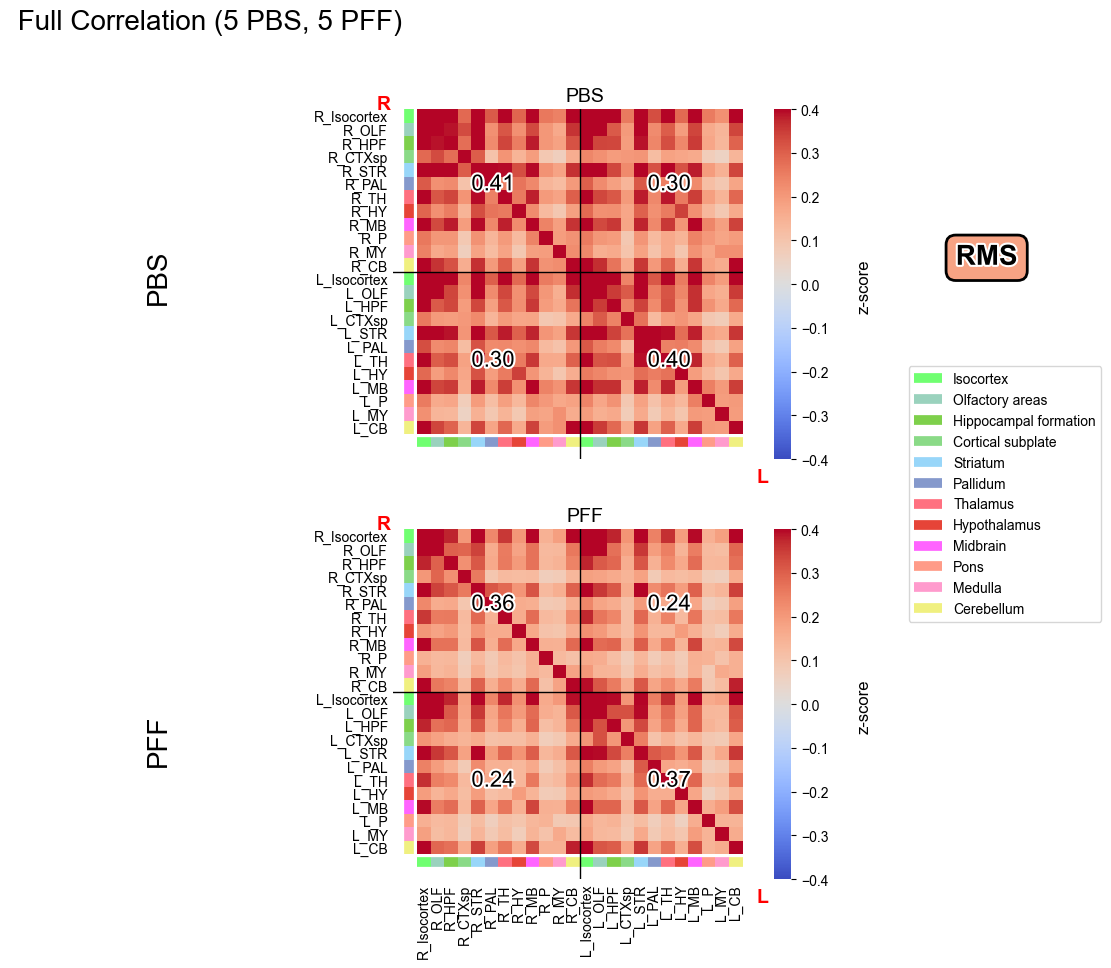

In [7]:
from nilearn import plotting

# create a six subplots figure
fig, axs = plt.subplots(2, 1, figsize=(20, 10))
# fig.suptitle(f'Apoe3 \n PBS Baseline')
# plot the first subplot using plotting
fig.suptitle(f' Full Correlation ({PBS_n_subjects} PBS, {PFF_n_subjects} PFF)', fontsize=20)
vmin_val = -0.4
vmax_val = 0.4
title_font = 14
title_y_pos = 1
title_x_pos = 0.55
cbar_x_pos = 33
cbar_y_pos = 13
quadrant_color = 'black'
quadrant_fontsize = 16



plot_unsym_conn_mat(
    axs[0],
    PBS_s1_correlation,

    regions_list=labels_12_list,
    # labels=labels_12_list,
    show_yaxis_labels=True,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    # grid=False,
    colorbar=True,
    cmap='coolwarm',
    # auto_fit=True,

)
axs[0].set_title('PBS', fontsize=title_font, y=title_y_pos, x=title_x_pos)
axs[0].text(cbar_x_pos, cbar_y_pos,  'z-score', fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')
axs[0].text(4,6, f"{PBS_s1_correlation_quadrant[0,0]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")] )
axs[0].text(17,6, f"{PBS_s1_correlation_quadrant[0,1]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")])
axs[0].text(4,19, f"{PBS_s1_correlation_quadrant[1,0]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")])
axs[0].text(17,19, f"{PBS_s1_correlation_quadrant[1,1]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")] )

# [0,0]
plot_unsym_conn_mat(
    axs[1],
    PFF_s1_correlation,


    regions_list=labels_12_list,
    labels=labels_12_list,
    show_yaxis_labels=True,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    # grid=False,
    colorbar=True,
    cmap='coolwarm',
    # auto_fit=True,

)
axs[1].set_title('PFF', fontsize=title_font, y=title_y_pos, x=title_x_pos)
axs[1].text(cbar_x_pos, cbar_y_pos,  'z-score', fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')
axs[1].text(4,6, f"{PFF_s1_correlation_quadrant[0,0]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")] )
axs[1].text(17,6, f"{PFF_s1_correlation_quadrant[0,1]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")])
axs[1].text(4,19, f"{PFF_s1_correlation_quadrant[1,0]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")])
axs[1].text(17,19, f"{PFF_s1_correlation_quadrant[1,1]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")] )

# [1]


for ax in axs.flat:
    ax.grid(False)
    # remove the horizontal and vertical lines around the matrix
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    ax.hlines(y=24.58, xmin=0, xmax=1, colors="#70FF71", linewidth=7, label="Isocortex", antialiased=True)
    ax.hlines(y=24.58, xmin=1, xmax=2, colors="#9AD2BD", linewidth=7, label="Olfactory areas", antialiased=True)
    ax.hlines(y=24.58, xmin=2, xmax=3, colors="#7ED04B", linewidth=7, label="Hippocampal formation", antialiased=True)
    ax.hlines(y=24.58, xmin=3, xmax=4, colors="#8ADA87", linewidth=7,label="Cortical subplate", antialiased=True)
    ax.hlines(y=24.58, xmin=4, xmax=5, colors="#98D6F9", linewidth=7, label="Striatum", antialiased=True)
    ax.hlines(y=24.58, xmin=5, xmax=6, colors="#8599CC", linewidth=7, label="Pallidum", antialiased=True)
    ax.hlines(y=24.58, xmin=6, xmax=7, colors="#FF7080", linewidth=7, label="Thalamus", antialiased=True)
    ax.hlines(y=24.58, xmin=7, xmax=8, colors="#E64438", linewidth=7, label="Hypothalamus", antialiased=True)
    ax.hlines(y=24.58, xmin=8, xmax=9, colors="#FF64FF", linewidth=7, label="Midbrain", antialiased=True)
    ax.hlines(y=24.58, xmin=9, xmax=10, colors="#FF9B88", linewidth=7, label="Pons", antialiased=True)
    ax.hlines(y=24.58, xmin=10, xmax=11, colors="#FF9BCD", linewidth=7, label="Medulla", antialiased=True)
    ax.hlines(y=24.58, xmin=11, xmax=12, colors="#F0F080", linewidth=7, label="Cerebellum", antialiased=True)

    ax.hlines(y=24.58, xmin=12, xmax=13, colors="#70FF71", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=13, xmax=14, colors="#9AD2BD", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=14, xmax=15, colors="#7ED04B", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=15, xmax=16, colors="#8ADA87", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=16, xmax=17, colors="#98D6F9", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=17, xmax=18, colors="#8599CC", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=18, xmax=19, colors="#FF7080", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=19, xmax=20, colors="#E64438", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=20, xmax=21, colors="#FF64FF", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=21, xmax=22, colors="#FF9B88", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=22, xmax=23, colors="#FF9BCD", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=23, xmax=24, colors="#F0F080", linewidth=7, antialiased=True)
# -------
    ax.vlines(x=-0.58, ymin=0, ymax=1, colors="#70FF71", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=1, ymax=2, colors="#9AD2BD", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=2, ymax=3, colors="#7ED04B", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=3, ymax=4, colors="#8ADA87", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=4, ymax=5, colors="#98D6F9", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=5, ymax=6, colors="#8599CC", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=6, ymax=7, colors="#FF7080", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=7, ymax=8, colors="#E64438", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=8, ymax=9, colors="#FF64FF", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=9, ymax=10, colors="#FF9B88", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=10, ymax=11, colors="#FF9BCD", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=11, ymax=12, colors="#F0F080", linewidth=7, antialiased=True)

    ax.vlines(x=-0.58, ymin=12, ymax=13, colors="#70FF71", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=13, ymax=14, colors="#9AD2BD", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=14, ymax=15, colors="#7ED04B", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=15, ymax=16, colors="#8ADA87", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=16, ymax=17, colors="#98D6F9", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=17, ymax=18, colors="#8599CC", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=18, ymax=19, colors="#FF7080", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=19, ymax=20, colors="#E64438", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=20, ymax=21, colors="#FF64FF", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=21, ymax=22, colors="#FF9B88", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=22, ymax=23, colors="#FF9BCD", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=23, ymax=24, colors="#F0F080", linewidth=7, antialiased=True)
    # draw a black horizontal line
    ax.axvline(x=12, color="black", linewidth=1, antialiased=True)
    ax.axhline(y=12, color="black", linewidth=1, antialiased=True)

    ax.text(x=-3, y=0, s="R", fontsize=14, color="red", weight="bold", )
    ax.text(x=25, y=27.5, s="L", fontsize=14, color="red", weight="bold", )
    ax.tick_params(axis="both", bottom=False, top=False, left=False, right=False)


ax.legend(loc='center', bbox_to_anchor=(1.75, 1.1))
ax.text(-20,-17, "PBS", fontsize=20, rotation=90)
ax.text(-20,17, "PFF", fontsize=20, rotation=90)
ax.text(
    42, -20, "RMS",
    fontsize=20,
    color=quadrant_color,
    weight="bold",
    ha="center",
    va="center",
    path_effects=[pe.withStroke(linewidth=3, foreground="white")],
    bbox=dict(
        facecolor="#f7a384",
        edgecolor="black",
        boxstyle="round,pad=0.35",
        linewidth=2
    )
)

plt.savefig("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/correlation.svg")
plt.savefig("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/correlation.png")
plt.savefig("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/figures/correlation_.svg")
plt.show()

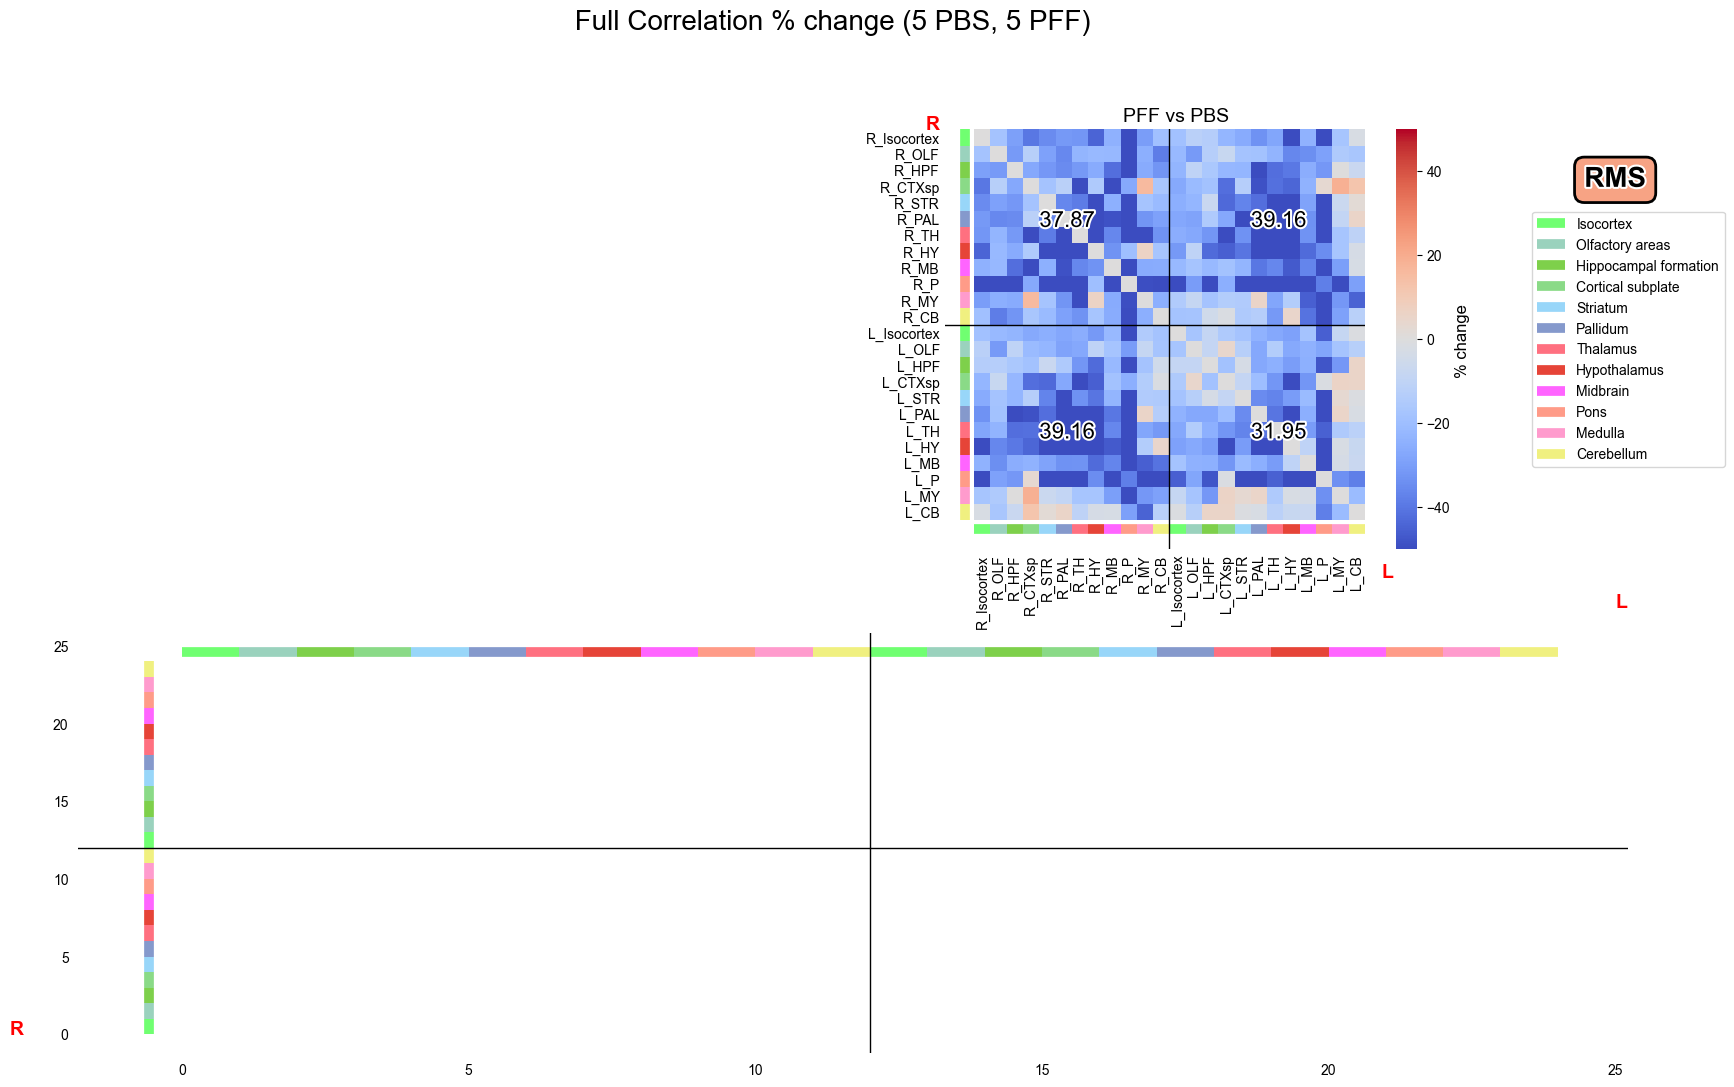

In [8]:
from nilearn import plotting

# create a six subplots figure
fig, axs = plt.subplots(2, 1, figsize=(20, 12))
# fig.suptitle(f'Apoe3 \n PBS Baseline')
# plot the first subplot using plotting
fig.suptitle(f' Full Correlation % change ({PBS_n_subjects} PBS, {PFF_n_subjects} PFF)', fontsize=20)
vmin_val = -50
vmax_val = 50
title_font = 14
title_y_pos = 1
title_x_pos = 0.55
cbar_x_pos = 30
cbar_y_pos = 13
quadrant_color = 'black'
quadrant_fontsize = 16



plot_unsym_conn_mat(
    axs[0],
    PFF_vs_PBS_correlation,

    regions_list=labels_12_list,
    labels=labels_12_list,
    show_yaxis_labels=True,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    # grid=False,
    colorbar=True,
    cmap='coolwarm',
    # auto_fit=True,

)
axs[0].set_title('PFF vs PBS', fontsize=title_font, y=title_y_pos, x=title_x_pos)
axs[0].text(cbar_x_pos, cbar_y_pos,  '% change', fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')
axs[0].text(4,6, f"{PFF_vs_PBS_correlation_quadrant[0,0]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")] )
axs[0].text(17,6, f"{PFF_vs_PBS_correlation_quadrant[0,1]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")])
axs[0].text(4,19, f"{PFF_vs_PBS_correlation_quadrant[1,0]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")])
axs[0].text(17,19, f"{PFF_vs_PBS_correlation_quadrant[1,1]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")] )

# [1]


for ax in axs.flat:
    ax.grid(False)
    # remove the horizontal and vertical lines around the matrix
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    ax.hlines(y=24.58, xmin=0, xmax=1, colors="#70FF71", linewidth=7, label="Isocortex", antialiased=True)
    ax.hlines(y=24.58, xmin=1, xmax=2, colors="#9AD2BD", linewidth=7, label="Olfactory areas", antialiased=True)
    ax.hlines(y=24.58, xmin=2, xmax=3, colors="#7ED04B", linewidth=7, label="Hippocampal formation", antialiased=True)
    ax.hlines(y=24.58, xmin=3, xmax=4, colors="#8ADA87", linewidth=7,label="Cortical subplate", antialiased=True)
    ax.hlines(y=24.58, xmin=4, xmax=5, colors="#98D6F9", linewidth=7, label="Striatum", antialiased=True)
    ax.hlines(y=24.58, xmin=5, xmax=6, colors="#8599CC", linewidth=7, label="Pallidum", antialiased=True)
    ax.hlines(y=24.58, xmin=6, xmax=7, colors="#FF7080", linewidth=7, label="Thalamus", antialiased=True)
    ax.hlines(y=24.58, xmin=7, xmax=8, colors="#E64438", linewidth=7, label="Hypothalamus", antialiased=True)
    ax.hlines(y=24.58, xmin=8, xmax=9, colors="#FF64FF", linewidth=7, label="Midbrain", antialiased=True)
    ax.hlines(y=24.58, xmin=9, xmax=10, colors="#FF9B88", linewidth=7, label="Pons", antialiased=True)
    ax.hlines(y=24.58, xmin=10, xmax=11, colors="#FF9BCD", linewidth=7, label="Medulla", antialiased=True)
    ax.hlines(y=24.58, xmin=11, xmax=12, colors="#F0F080", linewidth=7, label="Cerebellum", antialiased=True)

    ax.hlines(y=24.58, xmin=12, xmax=13, colors="#70FF71", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=13, xmax=14, colors="#9AD2BD", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=14, xmax=15, colors="#7ED04B", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=15, xmax=16, colors="#8ADA87", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=16, xmax=17, colors="#98D6F9", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=17, xmax=18, colors="#8599CC", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=18, xmax=19, colors="#FF7080", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=19, xmax=20, colors="#E64438", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=20, xmax=21, colors="#FF64FF", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=21, xmax=22, colors="#FF9B88", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=22, xmax=23, colors="#FF9BCD", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=23, xmax=24, colors="#F0F080", linewidth=7, antialiased=True)
# -------
    ax.vlines(x=-0.58, ymin=0, ymax=1, colors="#70FF71", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=1, ymax=2, colors="#9AD2BD", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=2, ymax=3, colors="#7ED04B", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=3, ymax=4, colors="#8ADA87", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=4, ymax=5, colors="#98D6F9", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=5, ymax=6, colors="#8599CC", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=6, ymax=7, colors="#FF7080", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=7, ymax=8, colors="#E64438", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=8, ymax=9, colors="#FF64FF", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=9, ymax=10, colors="#FF9B88", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=10, ymax=11, colors="#FF9BCD", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=11, ymax=12, colors="#F0F080", linewidth=7, antialiased=True)

    ax.vlines(x=-0.58, ymin=12, ymax=13, colors="#70FF71", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=13, ymax=14, colors="#9AD2BD", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=14, ymax=15, colors="#7ED04B", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=15, ymax=16, colors="#8ADA87", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=16, ymax=17, colors="#98D6F9", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=17, ymax=18, colors="#8599CC", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=18, ymax=19, colors="#FF7080", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=19, ymax=20, colors="#E64438", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=20, ymax=21, colors="#FF64FF", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=21, ymax=22, colors="#FF9B88", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=22, ymax=23, colors="#FF9BCD", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=23, ymax=24, colors="#F0F080", linewidth=7, antialiased=True)
    # draw a black horizontal line
    ax.axvline(x=12, color="black", linewidth=1, antialiased=True)
    ax.axhline(y=12, color="black", linewidth=1, antialiased=True)

    ax.text(x=-3, y=0, s="R", fontsize=14, color="red", weight="bold", )
    ax.text(x=25, y=27.5, s="L", fontsize=14, color="red", weight="bold", )
    ax.tick_params(axis="both", bottom=False, top=False, left=False, right=False)


ax.legend(loc='center', bbox_to_anchor=(1, 1.7))
# ax.text(-20,-17, "PBS", fontsize=20, rotation=90)
# ax.text(-20,17, "PFF", fontsize=20, rotation=90)
ax.text(
    25, 55, "RMS",
    fontsize=20,
    color=quadrant_color,
    weight="bold",
    ha="center",
    va="center",
    path_effects=[pe.withStroke(linewidth=3, foreground="white")],
    bbox=dict(
        facecolor="#f7a384",
        edgecolor="black",
        boxstyle="round,pad=0.35",
        linewidth=2
    )
)

plt.savefig("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/correlation_%_change.svg")
plt.savefig("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/correlation_%_change.png")
plt.savefig("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/figures/correlation_%_change.svg")
plt.show()

In [82]:

create_flattened_csv("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PBS_correlation.txt", "/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PBS_correlation.csv")

create_flattened_csv("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PFF_correlation.txt", "/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PFF_correlation.csv")

In [6]:
PBS_correlation_csv = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PBS_correlation.csv", delimiter=",")
PFF_correlation_csv = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PFF_correlation.csv", delimiter=",")

In [8]:
# PBS
# extract session 1 vs session 2 vs session 3
PBS_s1 = PBS_correlation_csv[:]
np.savetxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PBS_s1.csv", PBS_s1, delimiter=",")


# PFF
# extract session 1 vs session 2 vs session 3
PFF_s1 = PFF_correlation_csv[:]
np.savetxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PFF_s1.csv", PFF_s1, delimiter=",")



In [9]:
# now put them in same file
PBS_vs_PFF = np.concatenate((PBS_s1, PFF_s1), axis=0)
np.savetxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PBS_vs_PFF.csv", PBS_vs_PFF, delimiter=",")

In [86]:
%%bash
# palm PBS vs PFF
# s1_vs_s2_v3 (24) 9 subjects with 3 timepoints
design_PBS_vs_PFF="/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/UNPAIRED_stats_design/5_vs_5.mat"
contrast_PBS_vs_PFF="/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/UNPAIRED_stats_design/5_vs_5.con"
#EB_PBS_vs_PFF="/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/UNPAIRED_stats_design/EB_9.mat"


sub_list="/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PBS_vs_PFF.csv"
output_dir="/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation"
palm -i $sub_list -d ${design_PBS_vs_PFF} -t ${contrast_PBS_vs_PFF}  -o ${output_dir}/PBS_vs_PFF -n 10000  -fdr -ise -ee -corrcon




             ___         ___                         ___
            /  /\       /  /\                       /__/\
           /  /::\     /  /::\                     |  |::\
          /  /:/\:\   /  /:/\:\    ___     ___     |  |:|:\
         /  /:/~/:/  /  /:/~/::\  /__/\   /  /\  __|__|:|\:\
        /__/:/ /:/  /__/:/ /:/\:\ \  \:\ /  /:/ /__/::::| \:\
        \  \:\/:/   \  \:\/:/__\/  \  \:\  /:/  \  \:\~~\__\/
         \  \::/     \  \::/        \  \:\/:/    \  \:\
          \  \:\      \  \:\         \  \::/      \  \:\
           \  \:\      \  \:\         \__\/        \  \:\
            \__\/       \__\/                       \__\/

                 Permutation Analysis of Linear Models
Running PALM alpha119 using MATLAB 9.11.0.1809720 (R2021b) Update 1 with the following options:
-i /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PBS_vs_PFF.csv
-d /Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/UNPAIRED_stats_des

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



/2, Modality 1/1]
45.4%	 [Shuffling 4537/10000, Design 1/1, Contrast 2/2, Modality 1/1]
45.4%	 [Shuffling 4538/10000, Design 1/1, Contrast 1/2, Modality 1/1]
45.4%	 [Shuffling 4538/10000, Design 1/1, Contrast 2/2, Modality 1/1]
45.4%	 [Shuffling 4539/10000, Design 1/1, Contrast 1/2, Modality 1/1]
45.4%	 [Shuffling 4539/10000, Design 1/1, Contrast 2/2, Modality 1/1]
45.4%	 [Shuffling 4540/10000, Design 1/1, Contrast 1/2, Modality 1/1]
45.4%	 [Shuffling 4540/10000, Design 1/1, Contrast 2/2, Modality 1/1]
45.4%	 [Shuffling 4541/10000, Design 1/1, Contrast 1/2, Modality 1/1]
45.4%	 [Shuffling 4541/10000, Design 1/1, Contrast 2/2, Modality 1/1]
45.4%	 [Shuffling 4542/10000, Design 1/1, Contrast 1/2, Modality 1/1]
45.4%	 [Shuffling 4542/10000, Design 1/1, Contrast 2/2, Modality 1/1]
45.4%	 [Shuffling 4543/10000, Design 1/1, Contrast 1/2, Modality 1/1]
45.4%	 [Shuffling 4543/10000, Design 1/1, Contrast 2/2, Modality 1/1]
45.4%	 [Shuffling 4544/10000, Design 1/1, Contrast 1/2, Modality 1/1]
45

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



Design 1/1, Contrast 1/2, Modality 1/1]
96.5%	 [Shuffling 9654/10000, Design 1/1, Contrast 2/2, Modality 1/1]
96.5%	 [Shuffling 9655/10000, Design 1/1, Contrast 1/2, Modality 1/1]
96.5%	 [Shuffling 9655/10000, Design 1/1, Contrast 2/2, Modality 1/1]
96.6%	 [Shuffling 9656/10000, Design 1/1, Contrast 1/2, Modality 1/1]
96.6%	 [Shuffling 9656/10000, Design 1/1, Contrast 2/2, Modality 1/1]
96.6%	 [Shuffling 9657/10000, Design 1/1, Contrast 1/2, Modality 1/1]
96.6%	 [Shuffling 9657/10000, Design 1/1, Contrast 2/2, Modality 1/1]
96.6%	 [Shuffling 9658/10000, Design 1/1, Contrast 1/2, Modality 1/1]
96.6%	 [Shuffling 9658/10000, Design 1/1, Contrast 2/2, Modality 1/1]
96.6%	 [Shuffling 9659/10000, Design 1/1, Contrast 1/2, Modality 1/1]
96.6%	 [Shuffling 9659/10000, Design 1/1, Contrast 2/2, Modality 1/1]
96.6%	 [Shuffling 9660/10000, Design 1/1, Contrast 1/2, Modality 1/1]
96.6%	 [Shuffling 9660/10000, Design 1/1, Contrast 2/2, Modality 1/1]
96.6%	 [Shuffling 9661/10000, Design 1/1, Contrast

Error using exit
Unrecognized function or variable 'Settings'.
 
Error using exit
Unrecognized function or variable 'Settings'.
 


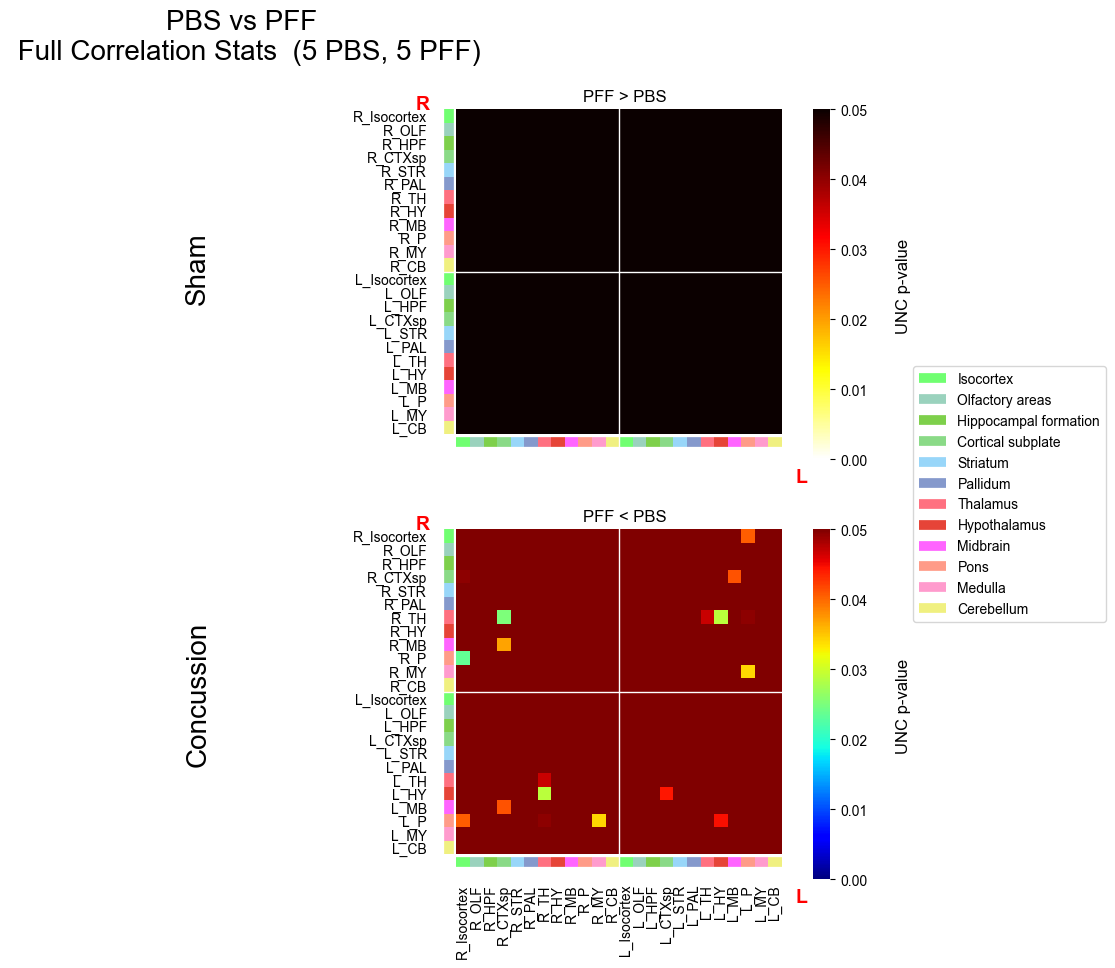

In [7]:

from nilearn import plotting
fig, axs = plt.subplots(2, 1, figsize=(20, 10))
fig.suptitle(f'PBS vs PFF \n Full Correlation Stats  ({PBS_n_subjects} PBS, {PFF_n_subjects} PFF)', fontsize=20)
vmin_val = 0
vmax_val = 0.05
title_font = 12
title_y_pos = 1
title_x_pos = 0.55

c_bar_x_pos = 33
c_bar_y_pos = 13

stat = "UNC"
cbar_legend = f"{stat} p-value"
stat_suffix = f"{stat.lower()}p"


# [0,0]
stats_PBS_VS_PFF_c2 = np.genfromtxt(f"/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PBS_vs_PFF_dat_tstat_{stat_suffix}_c2.csv", delimiter=",")
stats_PBS_VS_PFF_c2 = reshape_R_then_L_stats(stats_PBS_VS_PFF_c2, no_regions=no_roi)
# np.fill_diagonal(stats_PFF_s1_vs_s2_c2, 1)

plot_unsym_conn_mat(
    axs[0],
    stats_PBS_VS_PFF_c2,
    regions_list=labels_12_list,
    # labels=labels_12_list,
    show_yaxis_labels=True,
    colorbar=True,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    cmap='hot_r',

)
axs[0].set_title('PFF > PBS', fontsize=title_font, y=title_y_pos, x=title_x_pos)
axs[0].text(c_bar_x_pos, c_bar_y_pos,  cbar_legend, fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')

# [1,0]
stats_PBS_VS_PFF_c1 = np.genfromtxt(f"/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PBS_VS_PFF_dat_tstat_{stat_suffix}_c1.csv", delimiter=",")
stats_PBS_VS_PFF_c1 = reshape_R_then_L_stats(stats_PBS_VS_PFF_c1, no_regions=no_roi)
# np.fill_diagonal(stats_PBS_s1_vs_s2_c2, 1)

plot_unsym_conn_mat(
    axs[1],
    stats_PBS_VS_PFF_c1,
    regions_list=labels_12_list,
    labels=labels_12_list,
    show_yaxis_labels=True,
    colorbar=True,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    cmap='jet',

)
axs[1].set_title('PFF < PBS', fontsize=title_font, y=title_y_pos, x=title_x_pos)
axs[1].text(c_bar_x_pos, c_bar_y_pos,  cbar_legend, fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')



for ax in axs.flat:
    ax.grid(False)
    # remove the horizontal and vertical lines around the matrix
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    ax.hlines(y=24.58, xmin=0, xmax=1, colors="#70FF71", linewidth=7, label="Isocortex", antialiased=True)
    ax.hlines(y=24.58, xmin=1, xmax=2, colors="#9AD2BD", linewidth=7, label="Olfactory areas", antialiased=True)
    ax.hlines(y=24.58, xmin=2, xmax=3, colors="#7ED04B", linewidth=7, label="Hippocampal formation", antialiased=True)
    ax.hlines(y=24.58, xmin=3, xmax=4, colors="#8ADA87", linewidth=7,label="Cortical subplate", antialiased=True)
    ax.hlines(y=24.58, xmin=4, xmax=5, colors="#98D6F9", linewidth=7, label="Striatum", antialiased=True)
    ax.hlines(y=24.58, xmin=5, xmax=6, colors="#8599CC", linewidth=7, label="Pallidum", antialiased=True)
    ax.hlines(y=24.58, xmin=6, xmax=7, colors="#FF7080", linewidth=7, label="Thalamus", antialiased=True)
    ax.hlines(y=24.58, xmin=7, xmax=8, colors="#E64438", linewidth=7, label="Hypothalamus", antialiased=True)
    ax.hlines(y=24.58, xmin=8, xmax=9, colors="#FF64FF", linewidth=7, label="Midbrain", antialiased=True)
    ax.hlines(y=24.58, xmin=9, xmax=10, colors="#FF9B88", linewidth=7, label="Pons", antialiased=True)
    ax.hlines(y=24.58, xmin=10, xmax=11, colors="#FF9BCD", linewidth=7, label="Medulla", antialiased=True)
    ax.hlines(y=24.58, xmin=11, xmax=12, colors="#F0F080", linewidth=7, label="Cerebellum", antialiased=True)

    ax.hlines(y=24.58, xmin=12, xmax=13, colors="#70FF71", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=13, xmax=14, colors="#9AD2BD", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=14, xmax=15, colors="#7ED04B", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=15, xmax=16, colors="#8ADA87", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=16, xmax=17, colors="#98D6F9", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=17, xmax=18, colors="#8599CC", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=18, xmax=19, colors="#FF7080", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=19, xmax=20, colors="#E64438", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=20, xmax=21, colors="#FF64FF", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=21, xmax=22, colors="#FF9B88", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=22, xmax=23, colors="#FF9BCD", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=23, xmax=24, colors="#F0F080", linewidth=7, antialiased=True)
# -------
    ax.vlines(x=-0.58, ymin=0, ymax=1, colors="#70FF71", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=1, ymax=2, colors="#9AD2BD", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=2, ymax=3, colors="#7ED04B", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=3, ymax=4, colors="#8ADA87", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=4, ymax=5, colors="#98D6F9", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=5, ymax=6, colors="#8599CC", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=6, ymax=7, colors="#FF7080", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=7, ymax=8, colors="#E64438", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=8, ymax=9, colors="#FF64FF", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=9, ymax=10, colors="#FF9B88", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=10, ymax=11, colors="#FF9BCD", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=11, ymax=12, colors="#F0F080", linewidth=7, antialiased=True)

    ax.vlines(x=-0.58, ymin=12, ymax=13, colors="#70FF71", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=13, ymax=14, colors="#9AD2BD", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=14, ymax=15, colors="#7ED04B", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=15, ymax=16, colors="#8ADA87", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=16, ymax=17, colors="#98D6F9", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=17, ymax=18, colors="#8599CC", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=18, ymax=19, colors="#FF7080", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=19, ymax=20, colors="#E64438", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=20, ymax=21, colors="#FF64FF", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=21, ymax=22, colors="#FF9B88", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=22, ymax=23, colors="#FF9BCD", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=23, ymax=24, colors="#F0F080", linewidth=7, antialiased=True)

    ax.axvline(x=12, color="white", linewidth=1, antialiased=True)
    ax.axhline(y=12, color="white", linewidth=1, antialiased=True)
    ax.tick_params(axis="both", bottom=False, top=False, left=False, right=False)

    ax.text(x=-3, y=0, s="R", fontsize=14, color="red", weight="bold", )
    ax.text(x=25, y=27.5, s="L", fontsize=14, color="red", weight="bold", )
ax.legend(loc='center', bbox_to_anchor=(1.8, 1.3))
ax.legend(loc='center', bbox_to_anchor=(1.65, 1.1))
ax.text(-20,-17, "Sham", fontsize=20, rotation=90)
ax.text(-20,17, "Concussion", fontsize=20, rotation=90)


plt.savefig(f"/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/Correlation_stats__{stat.lower()}_c2.svg")
plt.savefig(f"/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/figures/correlation_stats__{stat.lower()}_c2_KDhet.svg")
plt.show()

# <font color="red">================circular plot====================



In [8]:
label_colors = [
"#70FF71",
"#9AD2BD",
"#7ED04B",
"#8ADA87",
"#98D6F9",
"#8599CC",
"#FF7080",
"#E64438",
"#FF64FF",
"#FF9B88",
"#FF9BCD",
"#F0F080",
"#70FF71",
"#9AD2BD",
"#7ED04B",
"#8ADA87",
"#98D6F9",
"#8599CC",
"#FF7080",
"#E64438",
"#FF64FF",
"#FF9B88",
"#FF9BCD",
"#F0F080",


]


In [9]:

# First, we reorder the labels based on their location in the left hemi
label_names = labels_12_list
lh_labels = [name for name in label_names if name.startswith("L")]


# For the right hemi
rh_labels =  ["R_" + label[2:]  for label in lh_labels]

# Save the plot order and create a circular layout
node_order = list()

node_order.extend(lh_labels)
node_order.extend(rh_labels[::-1])


node_angles = circular_layout(
    label_names, node_order, start_pos=90, group_boundaries=[0, len(label_names) / 2], group_sep=20, start_between=True
)



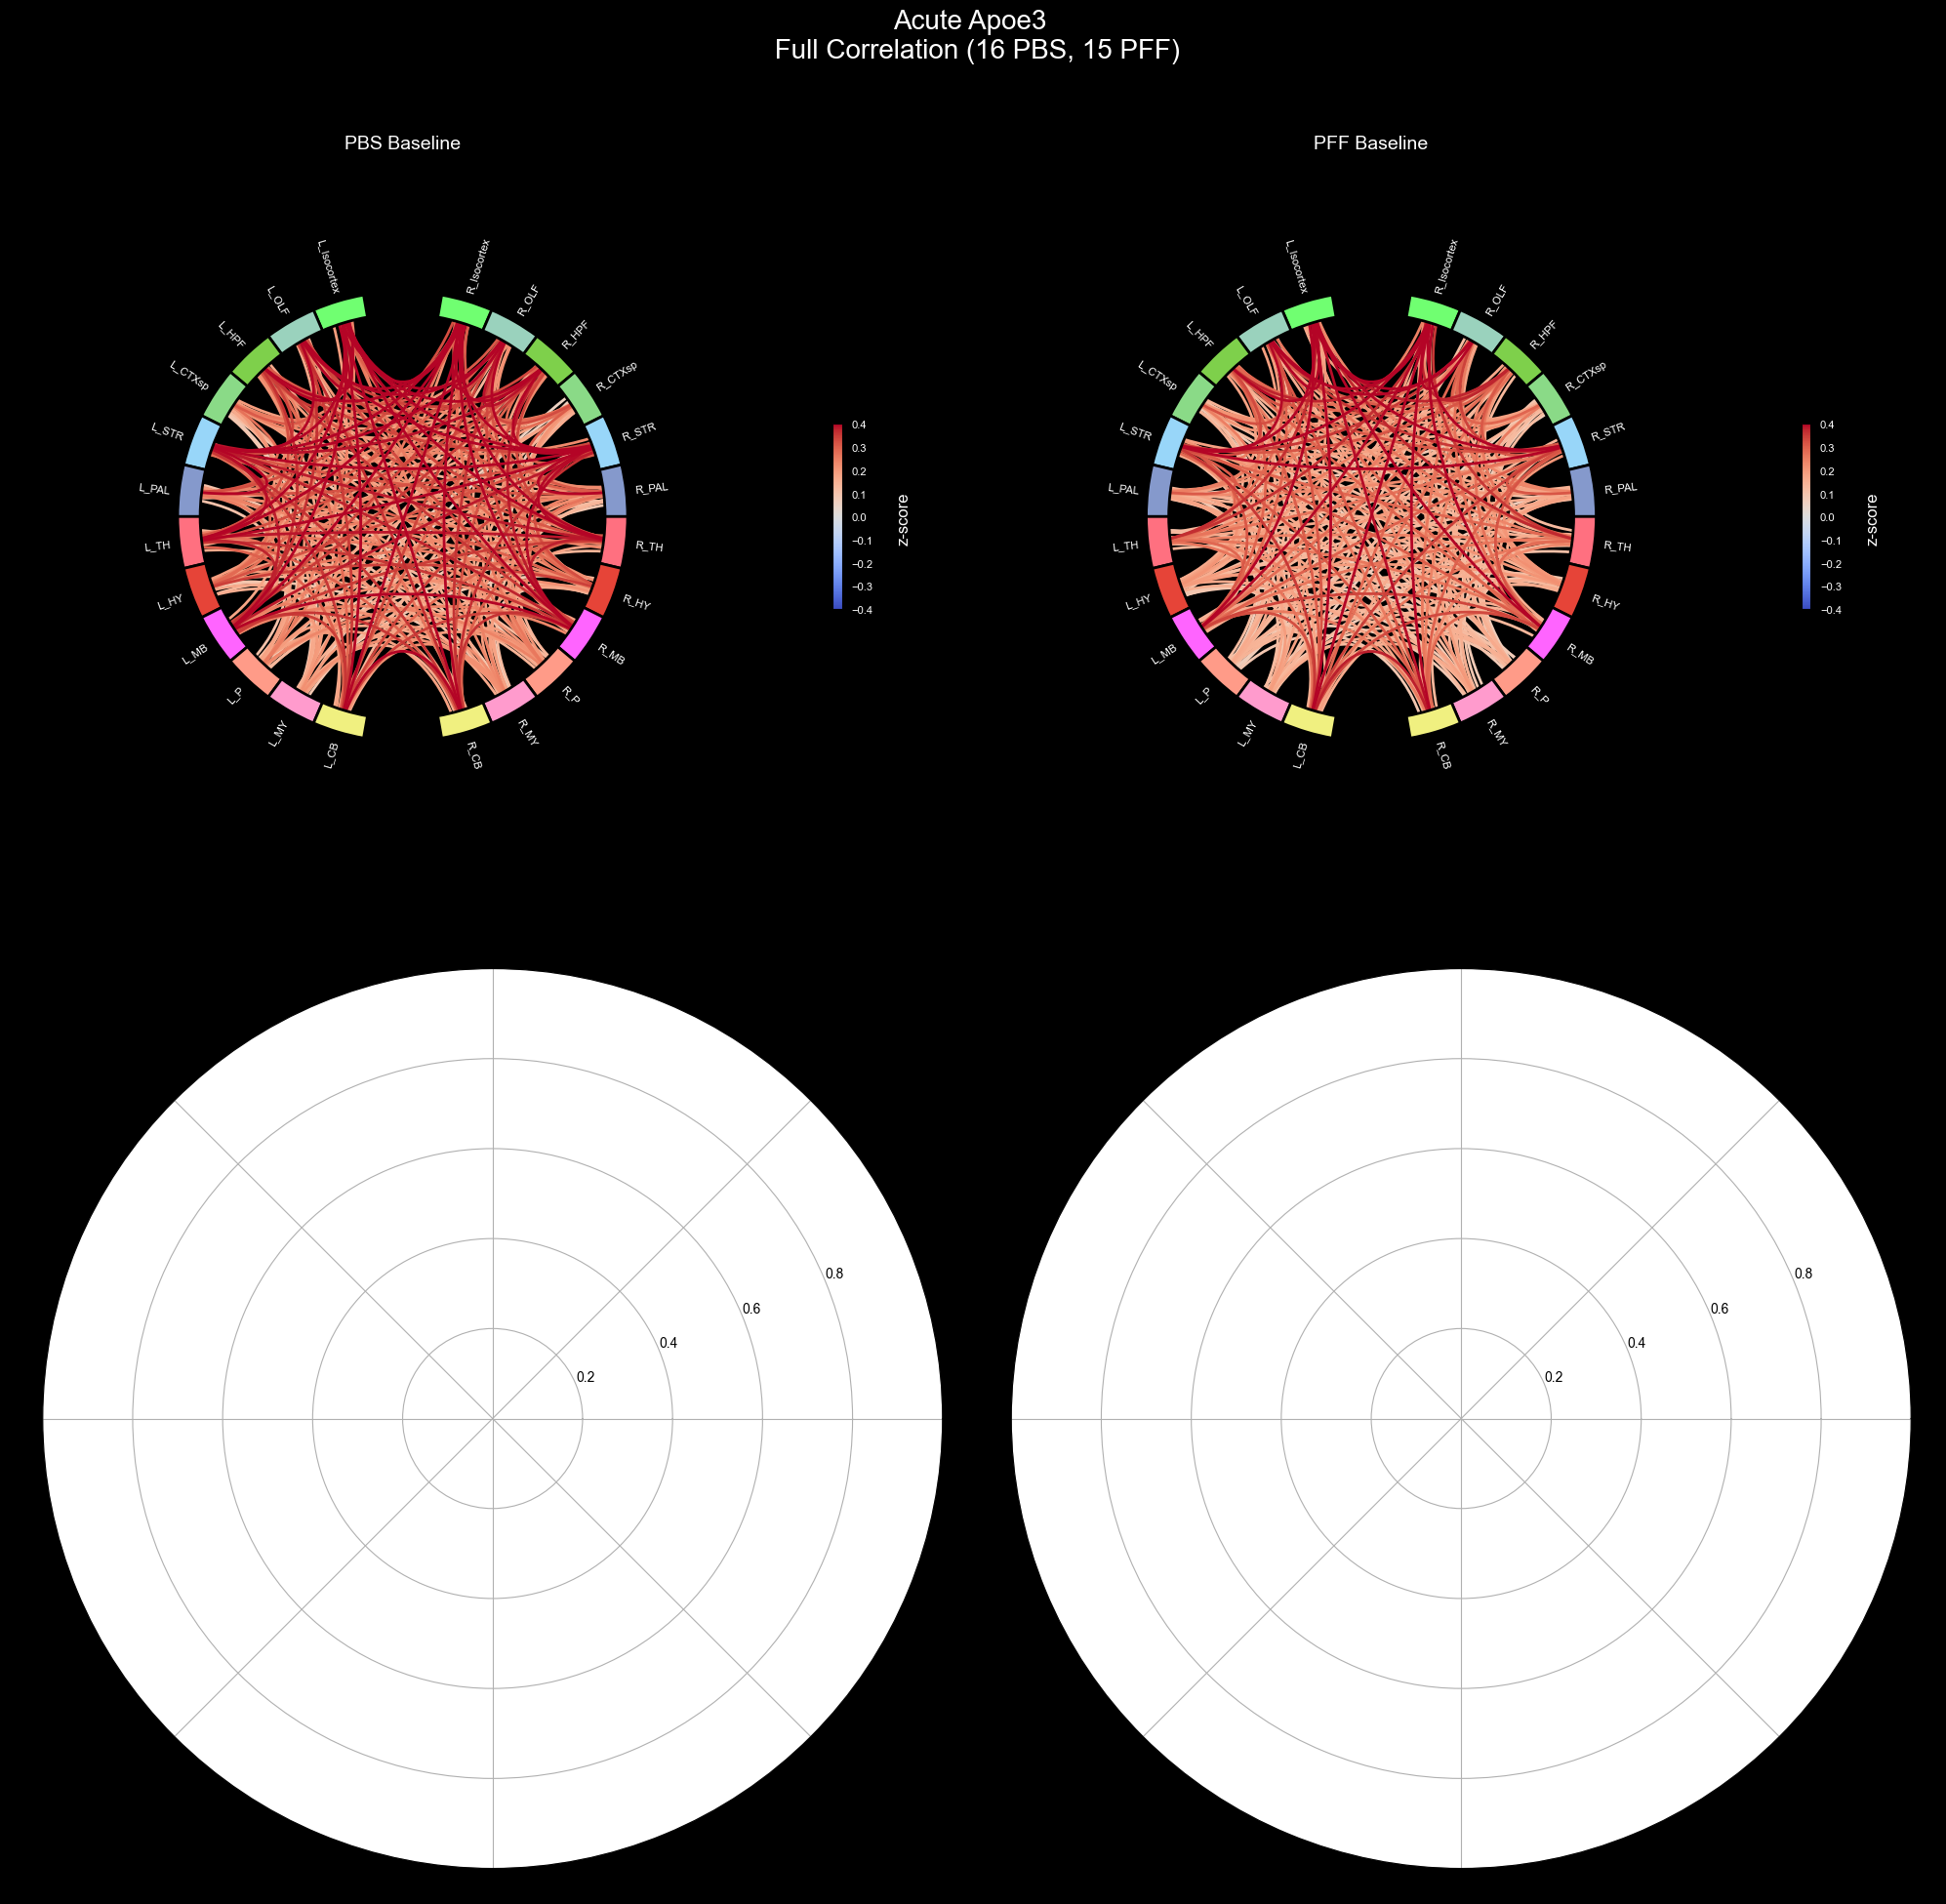

In [10]:
# Plot the graph using node colors from the FreeSurfer parcellation. We only
# show the 300 strongest connections.
# plot hyperparameters
vmin = -0.4
vmax = 0.4
n_lines = None
linewidths_conn = 2
colormap = "coolwarm"

# title hyperparameters
title_font = 14
title_y_pos = 1
title_x_pos = 0.5

# colorbar hyperparameters
colorbar_pos = (0.2, 0.5)
colorbar_title_pos1 = -0.05
colorbar_title_pos2 = 22


fig, axs = plt.subplots(2, 2, figsize=(20, 20), facecolor="black", subplot_kw=dict(polar=True))
fig.suptitle('Acute Apoe3 \n Full Correlation (16 PBS, 15 PFF)', fontsize=20, color="white")
fig.subplots_adjust(hspace=0.3, wspace=0.3)  # Adjust horizontal and vertical spacing
plot_connectivity_circle(
    PBS_s1_correlation,
    label_names,
    n_lines=n_lines,
    node_angles=node_angles,
    node_colors=label_colors,
    ax=axs[0, 0],
    colormap=colormap,
    vmin=vmin,
    vmax=vmax,
    linewidth=linewidths_conn,
    node_height=1,
    colorbar_pos=colorbar_pos,
    show=False
)
axs[0, 0].set_title('PBS Baseline', fontsize=title_font, y=title_y_pos, x=title_x_pos, color="white")
axs[0, 0].text(colorbar_title_pos1, colorbar_title_pos2,  'z-score', fontsize=12, rotation=90,  color="white")




plot_connectivity_circle(
    PFF_s1_correlation,
    label_names,
    n_lines=n_lines,
    node_angles=node_angles,
    node_colors=label_colors,
    ax=axs[0, 1],
    colormap=colormap,
    vmin=vmin,
    vmax=vmax,
    linewidth=linewidths_conn,
    node_height=1,
    colorbar_pos=colorbar_pos,
    show=False
)
axs[0, 1].set_title('PFF Baseline', fontsize=title_font, y=title_y_pos, x=title_x_pos, color="white")
axs[0, 1].text(colorbar_title_pos1, colorbar_title_pos2,  'z-score', fontsize=12, rotation=90,  color="white")




fig.tight_layout()
# save fig
fig.savefig("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/correlation_circular.svg")


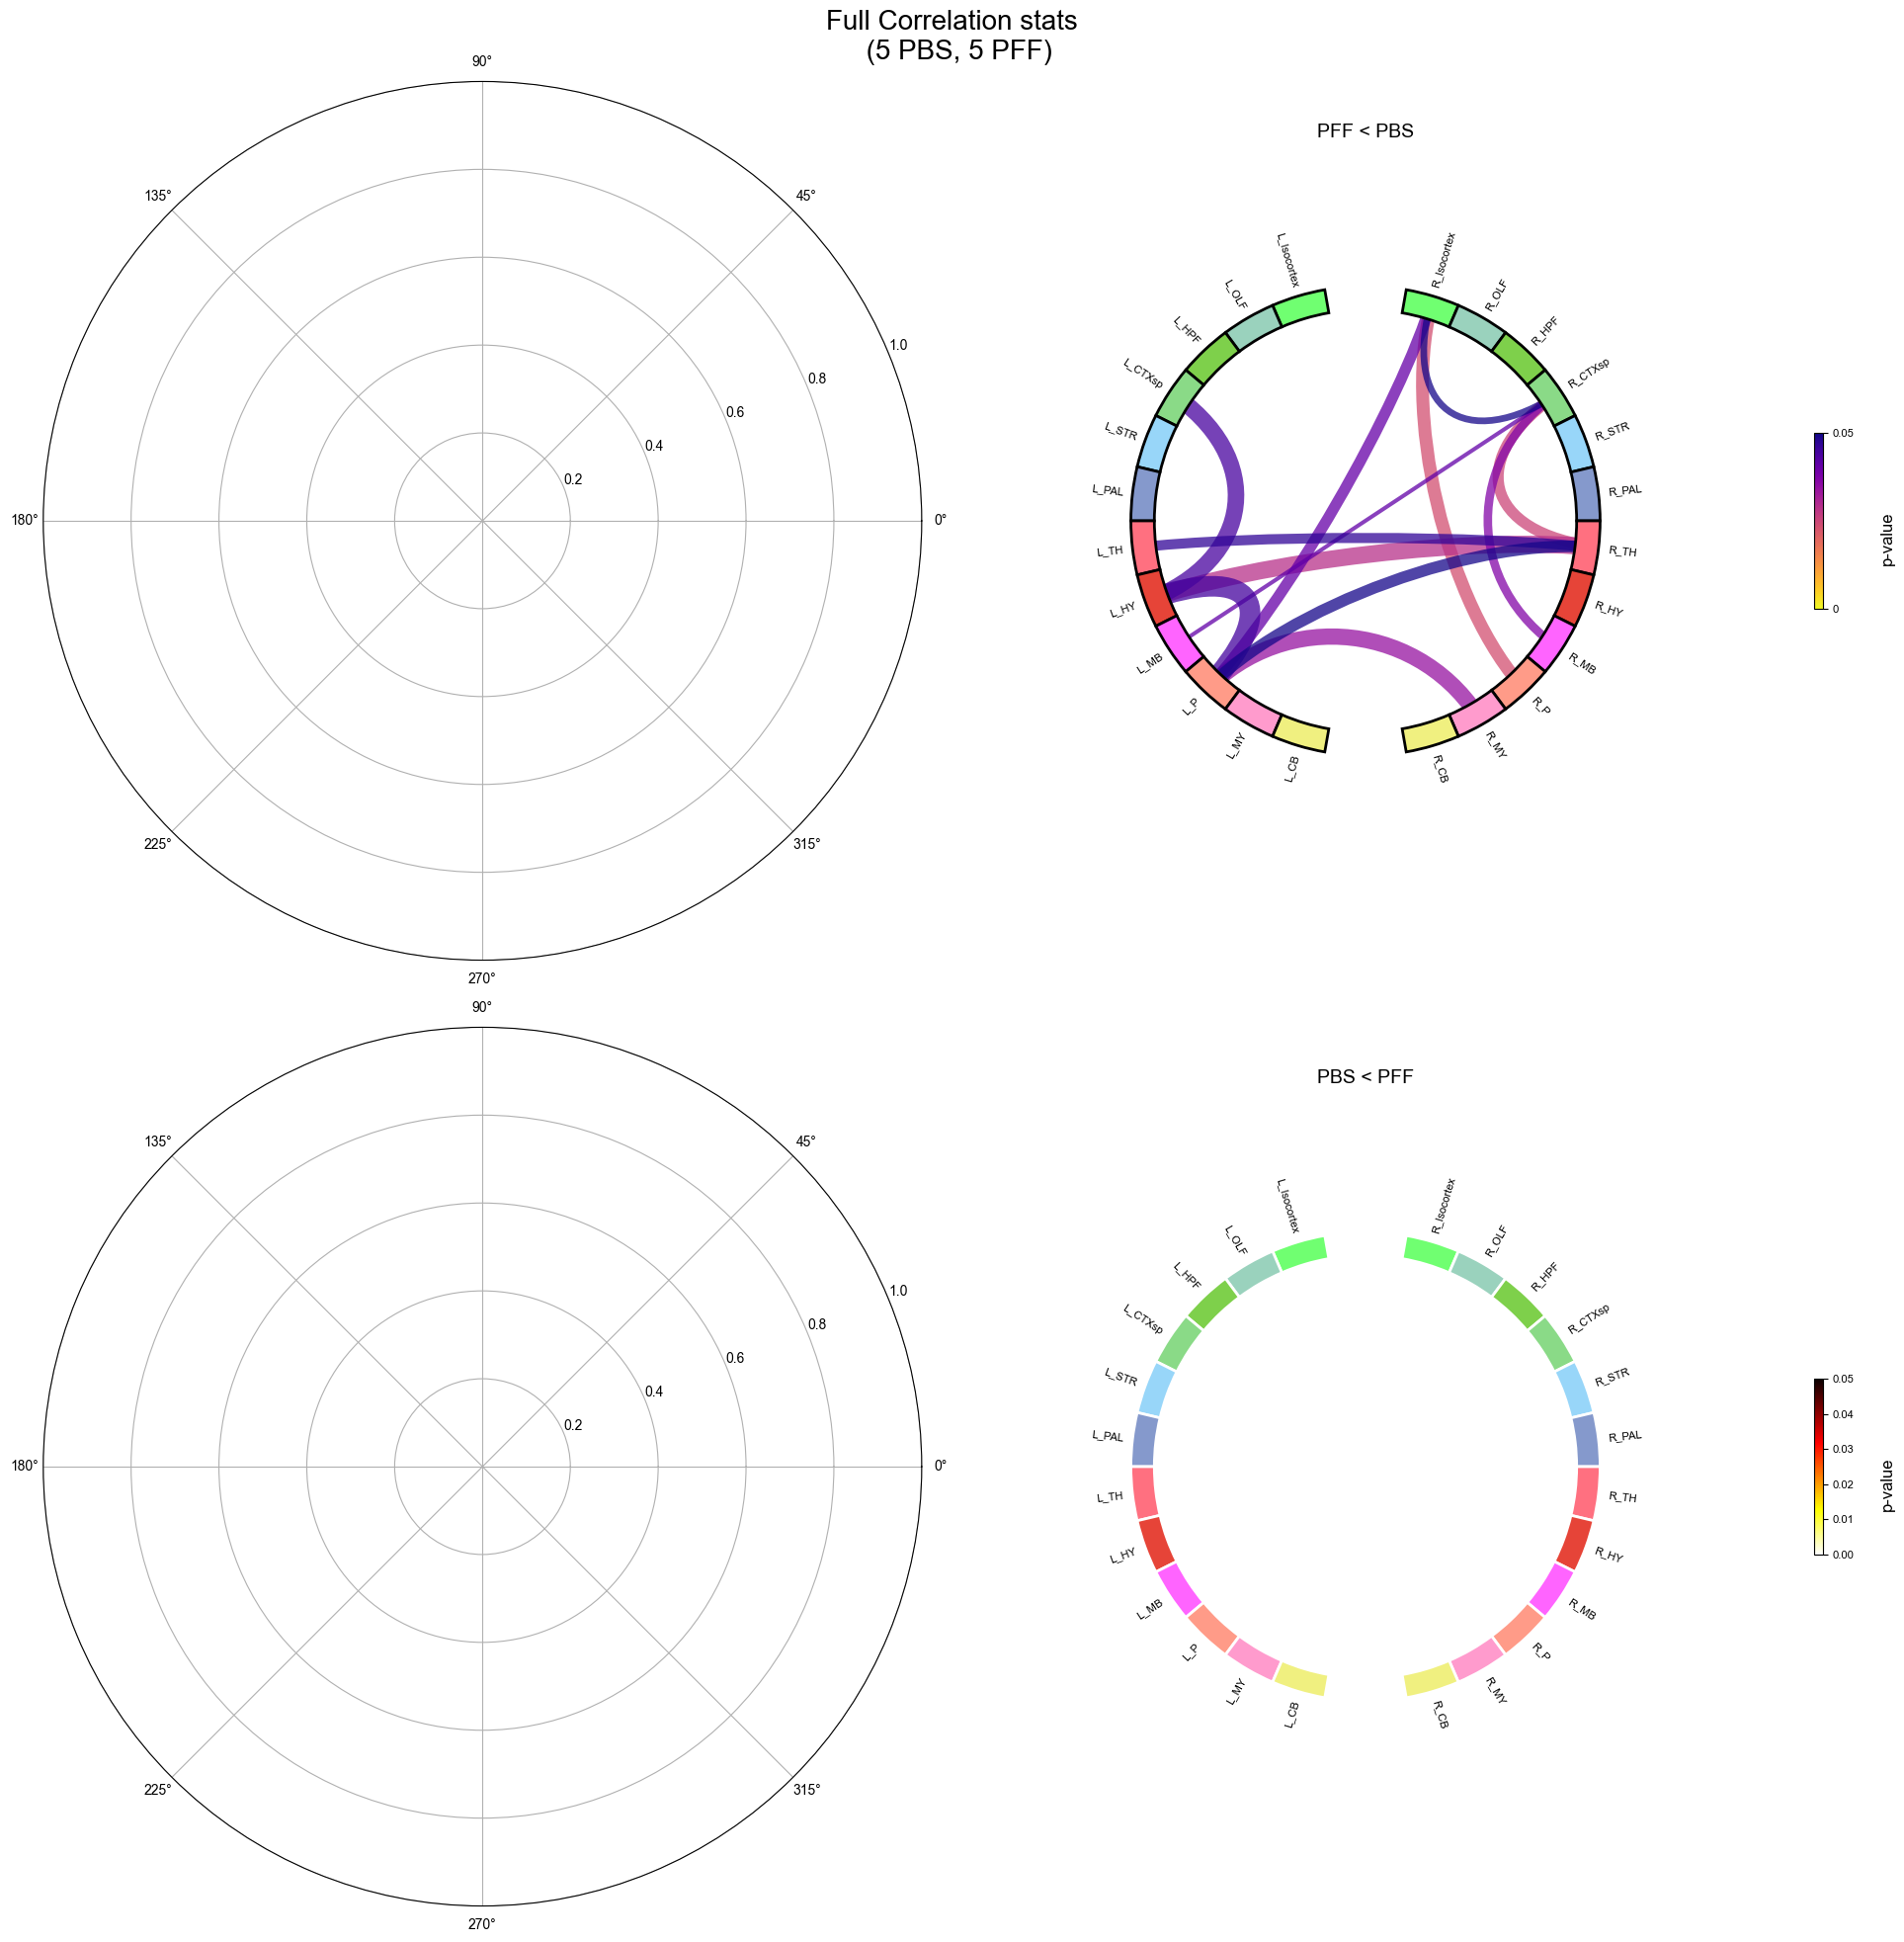

In [12]:
import importlib
# import my_module  # Replace with your module name
import sys

sys.path.append("/Users/aeed/Dropbox/SCRIPTS/functional_connectivity")
import FC_functions
importlib.reload(FC_functions)

from FC_functions import combine_list, average_csv_list, plot_pcolor_map, plot_conn_matrix, reduce_conn_matrix, plot_connectivity_circle2
# Reload the module



# Plot the graph using node colors from the FreeSurfer parcellation. We only
# show the 300 strongest connections.
# plot hyperparameters
vmax = 0.05
vmin = 0
n_lines = None
linewidths_conn = 5
colormap = "hot_r"

# title hyperparameters
title_font = 14
title_y_pos = 1
title_x_pos = 0.5

# colorbar hyperparameters
colorbar_pos = (0.2, 0.5)
colorbar_title_pos1 = -0.08
colorbar_title_pos2 = 22

mask_value = 0

fig, axs = plt.subplots(2, 2, figsize=(20, 20), facecolor="white", subplot_kw=dict(polar=True))
fig.suptitle('Full Correlation stats \n (5 PBS, 5 PFF)', fontsize=20, color="black")
fig.subplots_adjust(hspace=0.3, wspace=0.3)  # Adjust horizontal and vertical spacing

# remove any value bigger than 0.05




stats_PBS_VS_PFF_c1[stats_PBS_VS_PFF_c1 > 0.05] = mask_value
binary_sig = (stats_PBS_VS_PFF_c1 > 0).astype(int)
thickness = binary_sig * PFF_vs_PBS_correlation
thickness = np.abs(thickness)
plot_connectivity_circle2(
    stats_PBS_VS_PFF_c1,
    label_names,
    n_lines=200,
    node_angles=node_angles,
    node_colors=label_colors,
    ax=axs[0, 1],
    colormap="plasma_r",
    vmin=vmin,
    vmax=vmax,
    min_linewidth=0,   # Minimum line width
    max_linewidth=15,
    # thickness_vmin=10,
    # thickness_vmax=100,
    thickness_mat=thickness,
    node_height=1,
    colorbar_pos=colorbar_pos,
    show=False,
    facecolor="white",
    node_edgecolor="black",
    textcolor="black",
    min_alpha=0.75,
    max_alpha=0.75,
    # create alpha mat with the same shape but with ones
    # alpha_mat=thickness

)
axs[0, 1].set_title('PFF < PBS', fontsize=title_font, y=title_y_pos, x=title_x_pos, color="black")
axs[0, 1].text(colorbar_title_pos1, colorbar_title_pos2,  'p-value', fontsize=12, rotation=90,  color="black")


stats_PBS_VS_PFF_c2[stats_PBS_VS_PFF_c2 > 0.05] = mask_value
plot_connectivity_circle(
    stats_PBS_VS_PFF_c2,
    label_names,
    n_lines=n_lines,
    node_angles=node_angles,
    node_colors=label_colors,
    ax=axs[1, 1],
    colormap=colormap,
    vmin=vmin,
    vmax=vmax,
    linewidth=linewidths_conn,
    node_height=1,
    colorbar_pos=colorbar_pos,
    show=False,
    facecolor="white",
    node_edgecolor="white",
    textcolor="black"
)
axs[1, 1].set_title('PBS < PFF', fontsize=title_font, y=title_y_pos, x=title_x_pos, color="black")
axs[1, 1].text(colorbar_title_pos1, colorbar_title_pos2,  'p-value', fontsize=12, rotation=90,  color="black")

fig.tight_layout()
# save fig
fig.savefig("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/correlation_FDR_circular.svg")

In [114]:
thickness[thickness > 0].min()

23.977715919560154

In [115]:
thickness[thickness > 0].max()

123.6643337557092

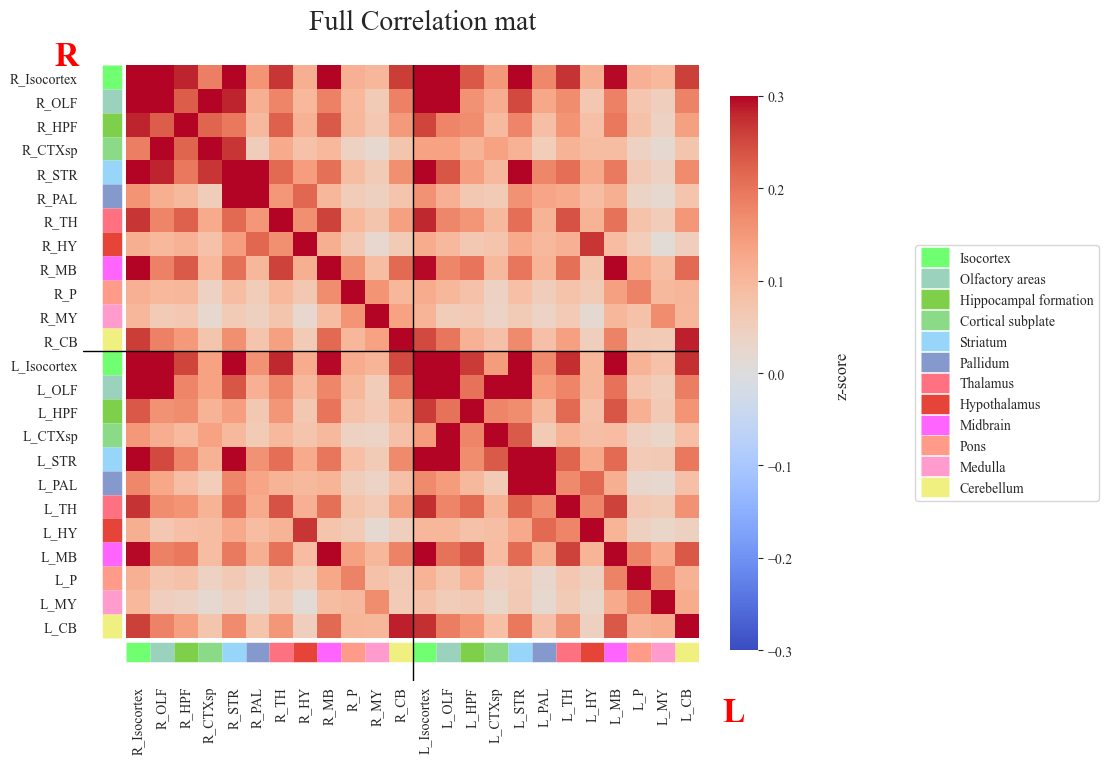

In [50]:
from nilearn import plotting

average_mat = (PFF_s1_correlation + PBS_s1_correlation) / 2
# create a six subplots figure
fig, axs = plt.subplots(figsize=(20, 8))
# fig.suptitle(f'Apoe3 \n PBS Baseline')
# plot the first subplot using plotting
fig.suptitle(f'Full Correlation mat', fontsize=20, x=0.63, y=0.95)
vmin_val = -0.3
vmax_val = 0.3
title_font = 14
title_y_pos = 1
title_x_pos = 0.55
cbar_x_pos = 30
cbar_y_pos = 13


plot_unsym_conn_mat(
    axs,
    average_mat,


    regions_list=labels_12_list,
    labels=labels_12_list,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    # grid=False,
    colorbar=True,
    cmap='coolwarm',
    # auto_fit=True,
    show_yaxis_labels = True,
    cbar_shrink=0.9


)
axs.set_title('', fontsize=title_font, y=title_y_pos, x=title_x_pos)
axs.text(cbar_x_pos, cbar_y_pos,  'z-score', fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')

axes = np.atleast_1d(axs)
for ax in axes:
    ax.grid(False)
    # remove the horizontal and vertical lines around the matrix
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    ax.hlines(y=24.58, xmin=0, xmax=1, colors="#70FF71", linewidth=14, label="Isocortex", antialiased=True)
    ax.hlines(y=24.58, xmin=1, xmax=2, colors="#9AD2BD", linewidth=14, label="Olfactory areas", antialiased=True)
    ax.hlines(y=24.58, xmin=2, xmax=3, colors="#7ED04B", linewidth=14, label="Hippocampal formation", antialiased=True)
    ax.hlines(y=24.58, xmin=3, xmax=4, colors="#8ADA87", linewidth=14,label="Cortical subplate", antialiased=True)
    ax.hlines(y=24.58, xmin=4, xmax=5, colors="#98D6F9", linewidth=14, label="Striatum", antialiased=True)
    ax.hlines(y=24.58, xmin=5, xmax=6, colors="#8599CC", linewidth=14, label="Pallidum", antialiased=True)
    ax.hlines(y=24.58, xmin=6, xmax=7, colors="#FF7080", linewidth=14, label="Thalamus", antialiased=True)
    ax.hlines(y=24.58, xmin=7, xmax=8, colors="#E64438", linewidth=14, label="Hypothalamus", antialiased=True)
    ax.hlines(y=24.58, xmin=8, xmax=9, colors="#FF64FF", linewidth=14, label="Midbrain", antialiased=True)
    ax.hlines(y=24.58, xmin=9, xmax=10, colors="#FF9B88", linewidth=14, label="Pons", antialiased=True)
    ax.hlines(y=24.58, xmin=10, xmax=11, colors="#FF9BCD", linewidth=14, label="Medulla", antialiased=True)
    ax.hlines(y=24.58, xmin=11, xmax=12, colors="#F0F080", linewidth=14, label="Cerebellum", antialiased=True)

    ax.hlines(y=24.58, xmin=12, xmax=13, colors="#70FF71", linewidth=14, antialiased=True)
    ax.hlines(y=24.58, xmin=13, xmax=14, colors="#9AD2BD", linewidth=14, antialiased=True)
    ax.hlines(y=24.58, xmin=14, xmax=15, colors="#7ED04B", linewidth=14, antialiased=True)
    ax.hlines(y=24.58, xmin=15, xmax=16, colors="#8ADA87", linewidth=14, antialiased=True)
    ax.hlines(y=24.58, xmin=16, xmax=17, colors="#98D6F9", linewidth=14, antialiased=True)
    ax.hlines(y=24.58, xmin=17, xmax=18, colors="#8599CC", linewidth=14, antialiased=True)
    ax.hlines(y=24.58, xmin=18, xmax=19, colors="#FF7080", linewidth=14, antialiased=True)
    ax.hlines(y=24.58, xmin=19, xmax=20, colors="#E64438", linewidth=14, antialiased=True)
    ax.hlines(y=24.58, xmin=20, xmax=21, colors="#FF64FF", linewidth=14, antialiased=True)
    ax.hlines(y=24.58, xmin=21, xmax=22, colors="#FF9B88", linewidth=14, antialiased=True)
    ax.hlines(y=24.58, xmin=22, xmax=23, colors="#FF9BCD", linewidth=14, antialiased=True)
    ax.hlines(y=24.58, xmin=23, xmax=24, colors="#F0F080", linewidth=14, antialiased=True)
# -------
    ax.vlines(x=-0.58, ymin=0, ymax=1, colors="#70FF71", linewidth=14, antialiased=True)
    ax.vlines(x=-0.58, ymin=1, ymax=2, colors="#9AD2BD", linewidth=14, antialiased=True)
    ax.vlines(x=-0.58, ymin=2, ymax=3, colors="#7ED04B", linewidth=14, antialiased=True)
    ax.vlines(x=-0.58, ymin=3, ymax=4, colors="#8ADA87", linewidth=14, antialiased=True)
    ax.vlines(x=-0.58, ymin=4, ymax=5, colors="#98D6F9", linewidth=14, antialiased=True)
    ax.vlines(x=-0.58, ymin=5, ymax=6, colors="#8599CC", linewidth=14, antialiased=True)
    ax.vlines(x=-0.58, ymin=6, ymax=7, colors="#FF7080", linewidth=14, antialiased=True)
    ax.vlines(x=-0.58, ymin=7, ymax=8, colors="#E64438", linewidth=14, antialiased=True)
    ax.vlines(x=-0.58, ymin=8, ymax=9, colors="#FF64FF", linewidth=14, antialiased=True)
    ax.vlines(x=-0.58, ymin=9, ymax=10, colors="#FF9B88", linewidth=14, antialiased=True)
    ax.vlines(x=-0.58, ymin=10, ymax=11, colors="#FF9BCD", linewidth=14,antialiased=True)
    ax.vlines(x=-0.58, ymin=11, ymax=12, colors="#F0F080", linewidth=14, antialiased=True)

    ax.vlines(x=-0.58, ymin=12, ymax=13, colors="#70FF71", linewidth=14, antialiased=True)
    ax.vlines(x=-0.58, ymin=13, ymax=14, colors="#9AD2BD", linewidth=14, antialiased=True)
    ax.vlines(x=-0.58, ymin=14, ymax=15, colors="#7ED04B", linewidth=14, antialiased=True)
    ax.vlines(x=-0.58, ymin=15, ymax=16, colors="#8ADA87", linewidth=14, antialiased=True)
    ax.vlines(x=-0.58, ymin=16, ymax=17, colors="#98D6F9", linewidth=14, antialiased=True)
    ax.vlines(x=-0.58, ymin=17, ymax=18, colors="#8599CC", linewidth=14, antialiased=True)
    ax.vlines(x=-0.58, ymin=18, ymax=19, colors="#FF7080", linewidth=14, antialiased=True)
    ax.vlines(x=-0.58, ymin=19, ymax=20, colors="#E64438", linewidth=14, antialiased=True)
    ax.vlines(x=-0.58, ymin=20, ymax=21, colors="#FF64FF", linewidth=14, antialiased=True)
    ax.vlines(x=-0.58, ymin=21, ymax=22, colors="#FF9B88", linewidth=14, antialiased=True)
    ax.vlines(x=-0.58, ymin=22, ymax=23, colors="#FF9BCD", linewidth=14, antialiased=True)
    ax.vlines(x=-0.58, ymin=23, ymax=24, colors="#F0F080", linewidth=14, antialiased=True)
    # draw a black horizontal line
    ax.axvline(x=12, color="black", linewidth=1, antialiased=True)
    ax.axhline(y=12, color="black", linewidth=1, antialiased=True)

    ax.text(x=-3, y=0, s="R", fontsize=24, color="red", weight="bold", )
    ax.text(x=25, y=27.5, s="L", fontsize=24, color="red", weight="bold", )


# ax.legend(loc='center', bbox_to_anchor=(1.8, 1.3))
ax.legend(loc='center', bbox_to_anchor=(1.5, 0.5))
ax.tick_params(axis="both", bottom=False, top=False, left=False, right=False)

plt.savefig("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation_mat_with_labels.svg")
plt.savefig("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation_mat_with_labels.png")

plt.savefig("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/figures/avergae_mat.svg")
plt.show()

In [28]:
labels_12_list

['R_Isocortex',
 'R_OLF',
 'R_HPF',
 'R_CTXsp',
 'R_STR',
 'R_PAL',
 'R_TH',
 'R_HY',
 'R_MB',
 'R_P',
 'R_MY',
 'R_CB',
 'L_Isocortex',
 'L_OLF',
 'L_HPF',
 'L_CTXsp',
 'L_STR',
 'L_PAL',
 'L_TH',
 'L_HY',
 'L_MB',
 'L_P',
 'L_MY',
 'L_CB']

In [8]:
from nilearn import plotting


pos_colors = [
    '#d01c8b4D',
    '#d01c8b4D',
    '#d01c8b',
    '#d01c8b',
]
neg_colors = [
    '#49525E',
    '#49525E',
    '#D5D5D5',
    '#D5D5D5',
]
#
#
# pos_colors = [
#  '#AE123A',
#  '#AE123A',
#  '#F4D166',
#  '#F4D166'
# ]
# # pos_colors = [
#  '#AE123A',
#  '#E84746',
#  '#F5A040',
#  '#F4D166'
# ]

colors = neg_colors + pos_colors
cmap = ListedColormap(colors)

# create a six subplots figure
fig, axs = plt.subplots(3, 2, figsize=(24, 16))
# fig.suptitle(f'Apoe3 \n PBS Baseline')
# plot the first subplot using plotting
fig.suptitle(f'1 year vs baseline', fontsize=20)
vmin_val = -100
vmax_val = 100
title_font = 14
title_y_pos = 1
title_x_pos = 0.55
cbar_x_pos = 30
cbar_y_pos = 13
cbar_legend = "% change"
colormap=cmap
quadrant_color = 'black'
quadrant_fontsize = 16


plot_unsym_conn_mat(
    axs[0, 0],
    PFF_s3_vs_s1_correlation_KDwt,


    regions_list=labels_12_list,
    # labels=labels_12_list,
    show_yaxis_labels=True,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    # grid=False,
    colorbar=True,
    cmap=colormap,
    cbar_shrink=0.9,
    # auto_fit=True,

)
axs[0, 0].set_title('PFF 1 year vs baseline \n WT', fontsize=title_font, y=title_y_pos, x=title_x_pos)
axs[0, 0].text(cbar_x_pos, cbar_y_pos,  cbar_legend, fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')
axs[0, 0].text(4,6, f"{PFF_s3_vs_s1_correlation_KDwt_quadrant[0,0]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")] )
axs[0, 0].text(17,6, f"{PFF_s3_vs_s1_correlation_KDwt_quadrant[0,1]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")])
axs[0, 0].text(4,19, f"{PFF_s3_vs_s1_correlation_KDwt_quadrant[1,0]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")])
axs[0, 0].text(17,19, f"{PFF_s3_vs_s1_correlation_KDwt_quadrant[1,1]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")] )
#[1, 1]
plot_unsym_conn_mat(
    axs[0, 1],
    PFF_s3_vs_s1_correlation_KDhet,


    regions_list=labels_12_list,
    # labels=labels_12_list,
    # show_yaxis_labels=True,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    # grid=False,
    colorbar=True,
    cmap=colormap,
    cbar_shrink=0.9,
    # auto_fit=True,

)
axs[0, 1].set_title('PFF 1 year vs baseline \n KDhet', fontsize=title_font, y=title_y_pos, x=title_x_pos)
axs[0, 1].text(cbar_x_pos, cbar_y_pos,  cbar_legend, fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')
axs[0, 1].text(4,6, f"{PFF_s3_vs_s1_correlation_KDhet_quadrant[0,0]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")] )
axs[0, 1].text(17,6, f"{PFF_s3_vs_s1_correlation_KDhet_quadrant[0,1]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")])
axs[0, 1].text(4,19, f"{PFF_s3_vs_s1_correlation_KDhet_quadrant[1,0]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")])
axs[0, 1].text(17,19, f"{PFF_s3_vs_s1_correlation_KDhet_quadrant[1,1]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")] )

# =========================================
#[1, 0]
plot_unsym_conn_mat(
    axs[1, 0],
    PFF_s3_vs_s1_correlation_KDwt,


    regions_list=labels_12_list,
    # labels=labels_12_list,
    show_yaxis_labels=True,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    # grid=False,
    colorbar=True,
    cmap=colormap,
    cbar_shrink=0.9,
    # auto_fit=True,

)
axs[1, 0].set_title('PFF 1 year vs baseline \n WT', fontsize=title_font, y=title_y_pos, x=title_x_pos)
axs[1, 0].text(cbar_x_pos, cbar_y_pos,  cbar_legend, fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')
axs[1, 0].text(4,6, f"{PFF_s3_vs_s1_correlation_KDwt_quadrant[0,0]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")] )
axs[1, 0].text(17,6, f"{PFF_s3_vs_s1_correlation_KDwt_quadrant[0,1]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")])
axs[1, 0].text(4,19, f"{PFF_s3_vs_s1_correlation_KDwt_quadrant[1,0]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")])
axs[1, 0].text(17,19, f"{PFF_s3_vs_s1_correlation_KDwt_quadrant[1,1]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")] )
# [1,1]
plot_unsym_conn_mat(
    axs[1, 1],
    PBS_s3_vs_s1_correlation_KDwt,


    regions_list=labels_12_list,
    # labels=labels_12_list,
    # show_yaxis_labels=True,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    # grid=False,
    colorbar=True,
    cmap=colormap,
    cbar_shrink=0.9,
    # auto_fit=True,

)
axs[1, 1].set_title('PBS 1 year vs baseline \n WT', fontsize=title_font, y=title_y_pos, x=title_x_pos)
axs[1, 1].text(cbar_x_pos, cbar_y_pos,  cbar_legend, fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')
axs[1, 1].text(4,6, f"{PBS_s3_vs_s1_correlation_KDwt_quadrant[0,0]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")] )
axs[1, 1].text(17,6, f"{PBS_s3_vs_s1_correlation_KDwt_quadrant[0,1]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")])
axs[1, 1].text(4,19, f"{PBS_s3_vs_s1_correlation_KDwt_quadrant[1,0]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")])
axs[1, 1].text(17,19, f"{PBS_s3_vs_s1_correlation_KDwt_quadrant[1,1]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")] )
# =======================================
# [2,0]
plot_unsym_conn_mat(
    axs[2, 0],
    PFF_s3_vs_s1_correlation_KDhet,


    regions_list=labels_12_list,
    labels=labels_12_list,
    show_yaxis_labels=True,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    # grid=False,
    colorbar=True,
    cmap=colormap,
    cbar_shrink=0.9,
    # auto_fit=True,

)
axs[2, 0].set_title('PFF 1 year vs baseline \n KDhet', fontsize=title_font, y=title_y_pos, x=title_x_pos)
axs[2, 0].text(cbar_x_pos, cbar_y_pos,  cbar_legend, fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')
axs[2, 0].text(4,6, f"{PFF_s3_vs_s1_correlation_KDhet_quadrant[0,0]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")] )
axs[2, 0].text(17,6, f"{PFF_s3_vs_s1_correlation_KDhet_quadrant[0,1]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")])
axs[2, 0].text(4,19, f"{PFF_s3_vs_s1_correlation_KDhet_quadrant[1,0]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")])
axs[2, 0].text(17,19, f"{PFF_s3_vs_s1_correlation_KDhet_quadrant[1,1]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")] )
# [2,1]
plot_unsym_conn_mat(
    axs[2, 1],
    PBS_s3_vs_s1_correlation_KDhet,


    regions_list=labels_12_list,
    labels=labels_12_list,
    # show_yaxis_labels=True,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    # grid=False,
    colorbar=True,
    cmap=colormap,
    cbar_shrink=0.9,
    # auto_fit=True,

)
axs[2, 1].set_title('PBS 1 year vs baseline \n KDhet', fontsize=title_font, y=title_y_pos, x=title_x_pos)
axs[2, 1].text(cbar_x_pos, cbar_y_pos,  cbar_legend, fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')
axs[2, 1].text(4,6, f"{PBS_s3_vs_s1_correlation_KDhet_quadrant[0,0]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")] )
axs[2, 1].text(17,6, f"{PBS_s3_vs_s1_correlation_KDhet_quadrant[0,1]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")])
axs[2, 1].text(4,19, f"{PBS_s3_vs_s1_correlation_KDhet_quadrant[1,0]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")])
axs[2, 1].text(17,19, f"{PBS_s3_vs_s1_correlation_KDhet_quadrant[1,1]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")] )
# [1, 0]


for ax in axs.flat:
    ax.grid(False)
    # remove the horizontal and vertical lines around the matrix
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    ax.hlines(y=24.58, xmin=0, xmax=1, colors="#70FF71", linewidth=7, label="Isocortex", antialiased=True)
    ax.hlines(y=24.58, xmin=1, xmax=2, colors="#9AD2BD", linewidth=7, label="Olfactory areas", antialiased=True)
    ax.hlines(y=24.58, xmin=2, xmax=3, colors="#7ED04B", linewidth=7, label="Hippocampal formation", antialiased=True)
    ax.hlines(y=24.58, xmin=3, xmax=4, colors="#8ADA87", linewidth=7,label="Cortical subplate", antialiased=True)
    ax.hlines(y=24.58, xmin=4, xmax=5, colors="#98D6F9", linewidth=7, label="Striatum", antialiased=True)
    ax.hlines(y=24.58, xmin=5, xmax=6, colors="#8599CC", linewidth=7, label="Pallidum", antialiased=True)
    ax.hlines(y=24.58, xmin=6, xmax=7, colors="#FF7080", linewidth=7, label="Thalamus", antialiased=True)
    ax.hlines(y=24.58, xmin=7, xmax=8, colors="#E64438", linewidth=7, label="Hypothalamus", antialiased=True)
    ax.hlines(y=24.58, xmin=8, xmax=9, colors="#FF64FF", linewidth=7, label="Midbrain", antialiased=True)
    ax.hlines(y=24.58, xmin=9, xmax=10, colors="#FF9B88", linewidth=7, label="Pons", antialiased=True)
    ax.hlines(y=24.58, xmin=10, xmax=11, colors="#FF9BCD", linewidth=7, label="Medulla", antialiased=True)
    ax.hlines(y=24.58, xmin=11, xmax=12, colors="#F0F080", linewidth=7, label="Cerebellum", antialiased=True)

    ax.hlines(y=24.58, xmin=12, xmax=13, colors="#70FF71", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=13, xmax=14, colors="#9AD2BD", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=14, xmax=15, colors="#7ED04B", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=15, xmax=16, colors="#8ADA87", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=16, xmax=17, colors="#98D6F9", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=17, xmax=18, colors="#8599CC", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=18, xmax=19, colors="#FF7080", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=19, xmax=20, colors="#E64438", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=20, xmax=21, colors="#FF64FF", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=21, xmax=22, colors="#FF9B88", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=22, xmax=23, colors="#FF9BCD", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=23, xmax=24, colors="#F0F080", linewidth=7, antialiased=True)
# -------
    ax.vlines(x=-0.58, ymin=0, ymax=1, colors="#70FF71", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=1, ymax=2, colors="#9AD2BD", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=2, ymax=3, colors="#7ED04B", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=3, ymax=4, colors="#8ADA87", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=4, ymax=5, colors="#98D6F9", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=5, ymax=6, colors="#8599CC", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=6, ymax=7, colors="#FF7080", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=7, ymax=8, colors="#E64438", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=8, ymax=9, colors="#FF64FF", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=9, ymax=10, colors="#FF9B88", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=10, ymax=11, colors="#FF9BCD", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=11, ymax=12, colors="#F0F080", linewidth=7, antialiased=True)

    ax.vlines(x=-0.58, ymin=12, ymax=13, colors="#70FF71", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=13, ymax=14, colors="#9AD2BD", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=14, ymax=15, colors="#7ED04B", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=15, ymax=16, colors="#8ADA87", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=16, ymax=17, colors="#98D6F9", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=17, ymax=18, colors="#8599CC", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=18, ymax=19, colors="#FF7080", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=19, ymax=20, colors="#E64438", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=20, ymax=21, colors="#FF64FF", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=21, ymax=22, colors="#FF9B88", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=22, ymax=23, colors="#FF9BCD", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=23, ymax=24, colors="#F0F080", linewidth=7, antialiased=True)
    # draw a black horizontal line
    ax.axvline(x=12, color="black", linewidth=1, antialiased=True)
    ax.axhline(y=12, color="black", linewidth=1, antialiased=True)

    ax.text(x=-3, y=0, s="R", fontsize=14, color="red", weight="bold", )
    ax.text(x=25, y=26.5, s="L", fontsize=14, color="red", weight="bold", )
    ax.tick_params(axis="both", bottom=False, top=False, left=False, right=False)

ax.legend(loc='center', bbox_to_anchor=(1.65, 1.1))
# ax.text(-110,-17, "Sham", fontsize=20, rotation=90)
# ax.text(-110,17, "Concussion", fontsize=20, rotation=90)
ax.text(
    42, -20, "RMS",
    fontsize=20,
    color=quadrant_color,
    weight="bold",
    ha="center",
    va="center",
    path_effects=[pe.withStroke(linewidth=3, foreground="white")],
    bbox=dict(
        facecolor="#d01c8b",
        edgecolor="black",
        boxstyle="round,pad=0.35",
        linewidth=2
    )
)

plt.savefig("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_KDwt_FC_12_ROI/correlation/correlation_percentage_change_1year_vs_baseline.svg")
plt.savefig("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_KDwt_FC_12_ROI/correlation/correlation_percentage_change_1year_vs_baseline.png")
plt.savefig("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/figures/correlation_percentage_change_1year_vs_baseline.svg")
plt.show()

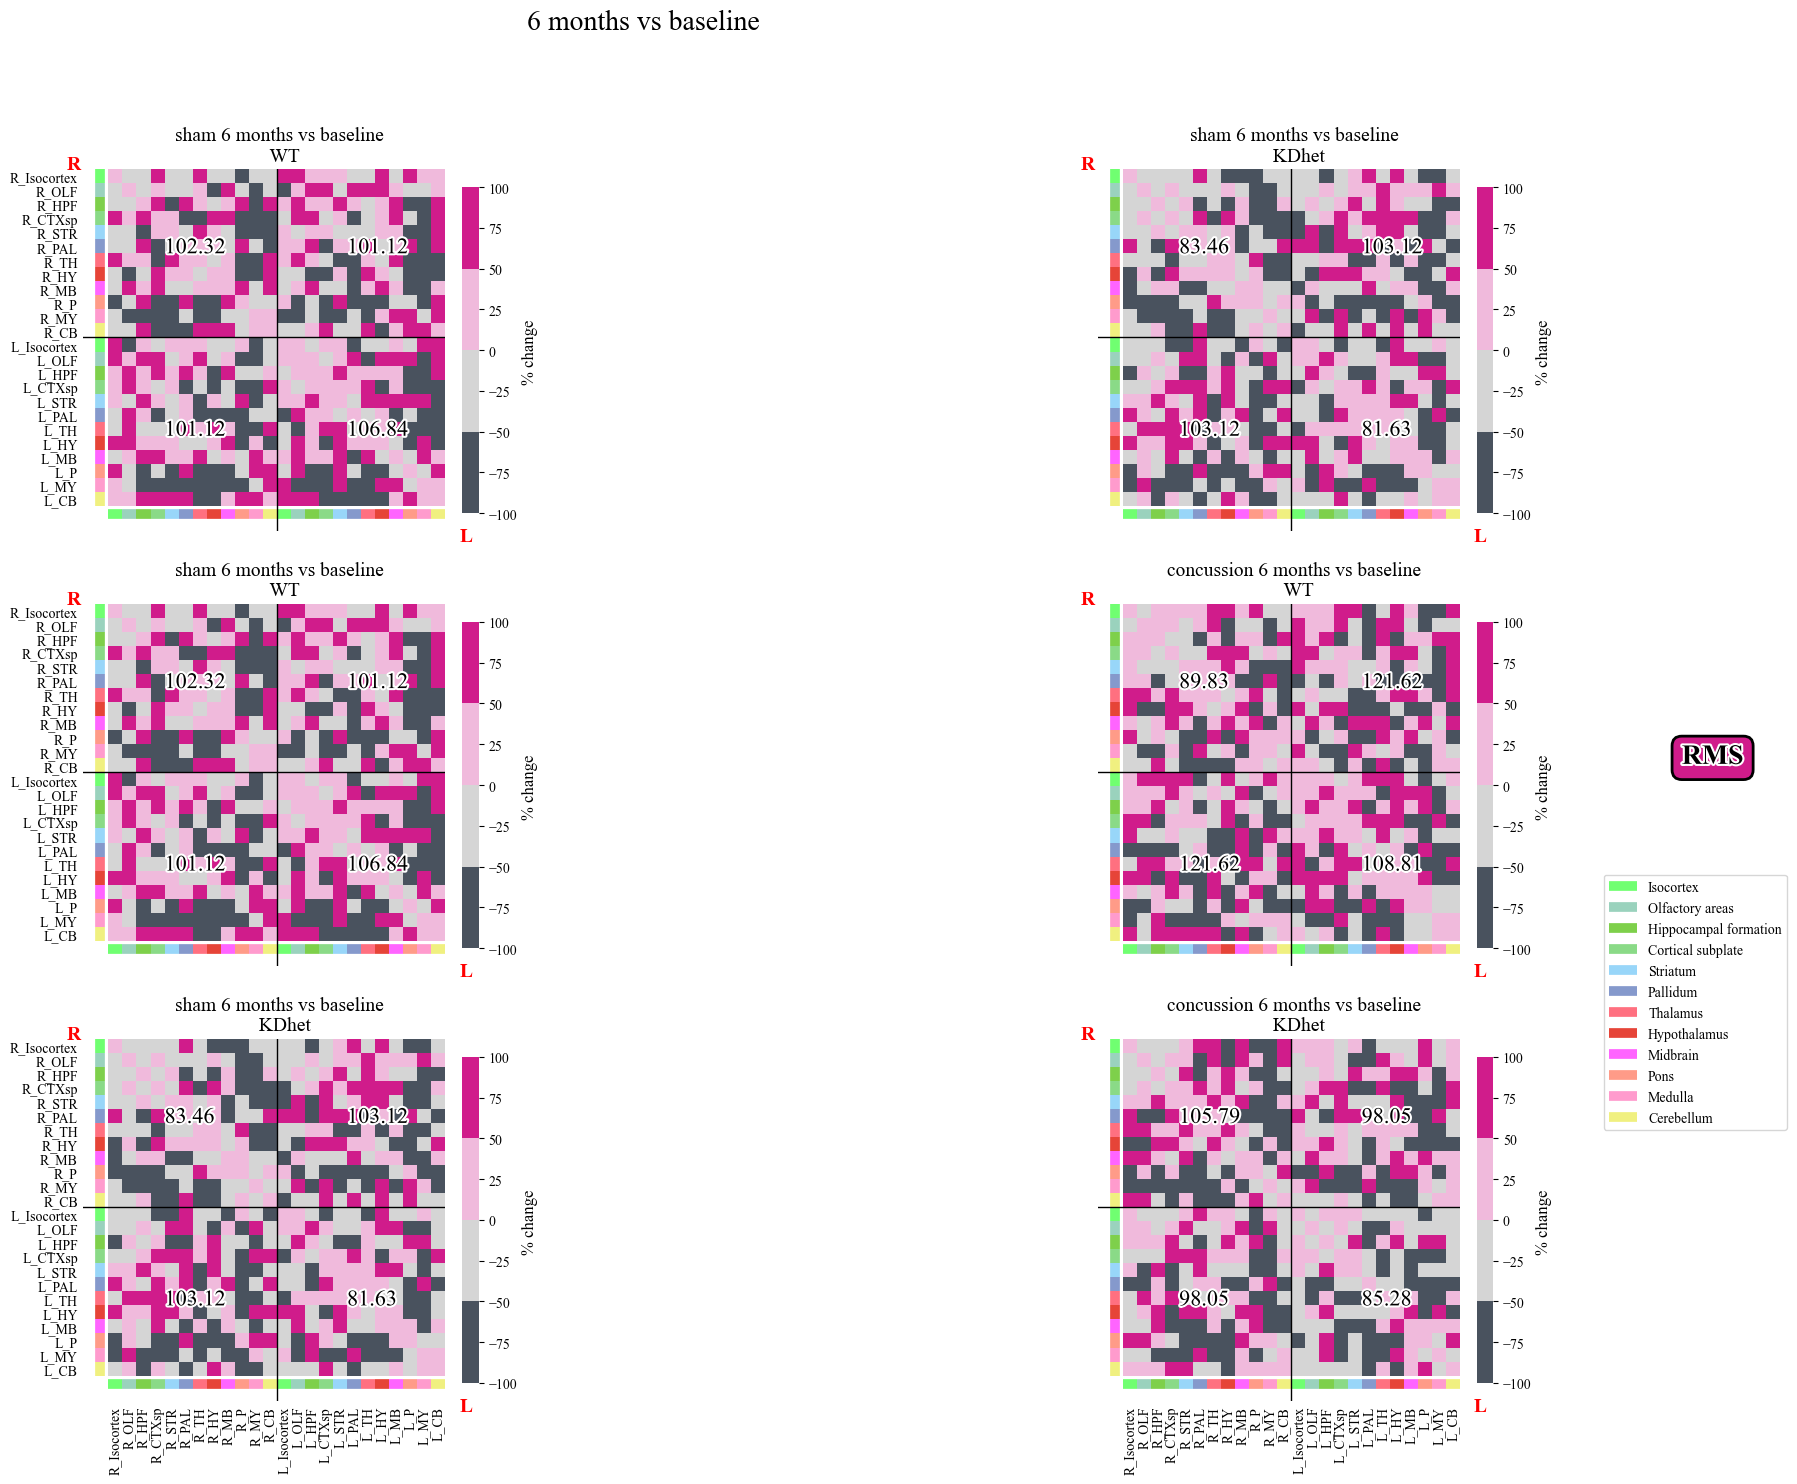

In [44]:
from nilearn import plotting


pos_colors = [
    '#d01c8b4D',
    '#d01c8b4D',
    '#d01c8b',
    '#d01c8b',
]
neg_colors = [
    '#49525E',
    '#49525E',
    '#D5D5D5',
    '#D5D5D5',
]
#
#
# pos_colors = [
#  '#AE123A',
#  '#AE123A',
#  '#F4D166',
#  '#F4D166'
# ]
# # pos_colors = [
#  '#AE123A',
#  '#E84746',
#  '#F5A040',
#  '#F4D166'
# ]

colors = neg_colors + pos_colors
cmap = ListedColormap(colors)

# create a six subplots figure
fig, axs = plt.subplots(3, 2, figsize=(24, 16))
# fig.suptitle(f'Apoe3 \n PBS Baseline')
# plot the first subplot using plotting
fig.suptitle(f'6 months vs baseline', fontsize=20)
vmin_val = -100
vmax_val = 100
title_font = 14
title_y_pos = 1
title_x_pos = 0.55
cbar_x_pos = 30
cbar_y_pos = 13
cbar_legend = "% change"
colormap=cmap
quadrant_color = 'black'
quadrant_fontsize = 16


plot_unsym_conn_mat(
    axs[0, 0],
    PFF_s2_vs_s1_correlation_KDwt,


    regions_list=labels_12_list,
    # labels=labels_12_list,
    show_yaxis_labels=True,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    # grid=False,
    colorbar=True,
    cmap=colormap,
    cbar_shrink = 0.9,
    # auto_fit=True,

)
axs[0, 0].set_title('PFF 6 months vs baseline \n WT', fontsize=title_font, y=title_y_pos, x=title_x_pos)
axs[0, 0].text(cbar_x_pos, cbar_y_pos,  cbar_legend, fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')
axs[0, 0].text(4,6, f"{PFF_s2_vs_s1_correlation_KDwt_quadrant[0,0]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")] )
axs[0, 0].text(17,6, f"{PFF_s2_vs_s1_correlation_KDwt_quadrant[0,1]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")])
axs[0, 0].text(4,19, f"{PFF_s2_vs_s1_correlation_KDwt_quadrant[1,0]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")])
axs[0, 0].text(17,19, f"{PFF_s2_vs_s1_correlation_KDwt_quadrant[1,1]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")] )
#[1, 1]
plot_unsym_conn_mat(
    axs[0, 1],
    PFF_s2_vs_s1_correlation_KDhet,


    regions_list=labels_12_list,
    # labels=labels_12_list,
    # show_yaxis_labels=True,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    # grid=False,
    colorbar=True,
    cmap=colormap,
    cbar_shrink = 0.9,
    # auto_fit=True,

)
axs[0, 1].set_title('PFF 6 months vs baseline \n KDhet', fontsize=title_font, y=title_y_pos, x=title_x_pos)
axs[0, 1].text(cbar_x_pos, cbar_y_pos,  cbar_legend, fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')
axs[0, 1].text(4,6, f"{PFF_s2_vs_s1_correlation_KDhet_quadrant[0,0]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")] )
axs[0, 1].text(17,6, f"{PFF_s2_vs_s1_correlation_KDhet_quadrant[0,1]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")])
axs[0, 1].text(4,19, f"{PFF_s2_vs_s1_correlation_KDhet_quadrant[1,0]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")])
axs[0, 1].text(17,19, f"{PFF_s2_vs_s1_correlation_KDhet_quadrant[1,1]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")] )

# =========================================
#[1, 0]
plot_unsym_conn_mat(
    axs[1, 0],
    PFF_s2_vs_s1_correlation_KDwt,


    regions_list=labels_12_list,
    # labels=labels_12_list,
    show_yaxis_labels=True,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    # grid=False,
    colorbar=True,
    cmap=colormap,
    cbar_shrink = 0.9,
    # auto_fit=True,

)
axs[1, 0].set_title('PFF 6 months vs baseline \n WT', fontsize=title_font, y=title_y_pos, x=title_x_pos)
axs[1, 0].text(cbar_x_pos, cbar_y_pos,  cbar_legend, fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')
axs[1, 0].text(4,6, f"{PFF_s2_vs_s1_correlation_KDwt_quadrant[0,0]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")] )
axs[1, 0].text(17,6, f"{PFF_s2_vs_s1_correlation_KDwt_quadrant[0,1]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")])
axs[1, 0].text(4,19, f"{PFF_s2_vs_s1_correlation_KDwt_quadrant[1,0]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")])
axs[1, 0].text(17,19, f"{PFF_s2_vs_s1_correlation_KDwt_quadrant[1,1]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")] )
# [1,1]
plot_unsym_conn_mat(
    axs[1, 1],
    PBS_s2_vs_s1_correlation_KDwt,


    regions_list=labels_12_list,
    # labels=labels_12_list,
    # show_yaxis_labels=True,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    # grid=False,
    colorbar=True,
    cmap=colormap,
    cbar_shrink = 0.9,
    # auto_fit=True,

)
axs[1, 1].set_title('PBS 6 months vs baseline \n WT', fontsize=title_font, y=title_y_pos, x=title_x_pos)
axs[1, 1].text(cbar_x_pos, cbar_y_pos,  cbar_legend, fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')
axs[1, 1].text(4,6, f"{PBS_s2_vs_s1_correlation_KDwt_quadrant[0,0]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")] )
axs[1, 1].text(17,6, f"{PBS_s2_vs_s1_correlation_KDwt_quadrant[0,1]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")])
axs[1, 1].text(4,19, f"{PBS_s2_vs_s1_correlation_KDwt_quadrant[1,0]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")])
axs[1, 1].text(17,19, f"{PBS_s2_vs_s1_correlation_KDwt_quadrant[1,1]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")] )
# =======================================
# [2,0]
plot_unsym_conn_mat(
    axs[2, 0],
    PFF_s2_vs_s1_correlation_KDhet,


    regions_list=labels_12_list,
    labels=labels_12_list,
    show_yaxis_labels=True,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    # grid=False,
    colorbar=True,
    cmap=colormap,
    cbar_shrink = 0.9,
    # auto_fit=True,

)
axs[2, 0].set_title('PFF 6 months vs baseline \n KDhet', fontsize=title_font, y=title_y_pos, x=title_x_pos)
axs[2, 0].text(cbar_x_pos, cbar_y_pos,  cbar_legend, fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')
axs[2, 0].text(4,6, f"{PFF_s2_vs_s1_correlation_KDhet_quadrant[0,0]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")] )
axs[2, 0].text(17,6, f"{PFF_s2_vs_s1_correlation_KDhet_quadrant[0,1]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")])
axs[2, 0].text(4,19, f"{PFF_s2_vs_s1_correlation_KDhet_quadrant[1,0]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")])
axs[2, 0].text(17,19, f"{PFF_s2_vs_s1_correlation_KDhet_quadrant[1,1]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")] )
# [2,1]
plot_unsym_conn_mat(
    axs[2, 1],
    PBS_s2_vs_s1_correlation_KDhet,


    regions_list=labels_12_list,
    labels=labels_12_list,
    # show_yaxis_labels=True,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    # grid=False,
    colorbar=True,
    cmap=colormap,
    cbar_shrink = 0.9,
    # auto_fit=True,

)
axs[2, 1].set_title('PBS 6 months vs baseline \n KDhet', fontsize=title_font, y=title_y_pos, x=title_x_pos)
axs[2, 1].text(cbar_x_pos, cbar_y_pos,  cbar_legend, fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')
axs[2, 1].text(4,6, f"{PBS_s2_vs_s1_correlation_KDhet_quadrant[0,0]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")] )
axs[2, 1].text(17,6, f"{PBS_s2_vs_s1_correlation_KDhet_quadrant[0,1]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")])
axs[2, 1].text(4,19, f"{PBS_s2_vs_s1_correlation_KDhet_quadrant[1,0]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")])
axs[2, 1].text(17,19, f"{PBS_s2_vs_s1_correlation_KDhet_quadrant[1,1]:.2f}", fontsize=quadrant_fontsize, color=quadrant_color, path_effects=[pe.withStroke(linewidth=3, foreground="white")] )
# [1, 0]


for ax in axs.flat:
    ax.grid(False)
    # remove the horizontal and vertical lines around the matrix
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    ax.hlines(y=24.58, xmin=0, xmax=1, colors="#70FF71", linewidth=7, label="Isocortex", antialiased=True)
    ax.hlines(y=24.58, xmin=1, xmax=2, colors="#9AD2BD", linewidth=7, label="Olfactory areas", antialiased=True)
    ax.hlines(y=24.58, xmin=2, xmax=3, colors="#7ED04B", linewidth=7, label="Hippocampal formation", antialiased=True)
    ax.hlines(y=24.58, xmin=3, xmax=4, colors="#8ADA87", linewidth=7,label="Cortical subplate", antialiased=True)
    ax.hlines(y=24.58, xmin=4, xmax=5, colors="#98D6F9", linewidth=7, label="Striatum", antialiased=True)
    ax.hlines(y=24.58, xmin=5, xmax=6, colors="#8599CC", linewidth=7, label="Pallidum", antialiased=True)
    ax.hlines(y=24.58, xmin=6, xmax=7, colors="#FF7080", linewidth=7, label="Thalamus", antialiased=True)
    ax.hlines(y=24.58, xmin=7, xmax=8, colors="#E64438", linewidth=7, label="Hypothalamus", antialiased=True)
    ax.hlines(y=24.58, xmin=8, xmax=9, colors="#FF64FF", linewidth=7, label="Midbrain", antialiased=True)
    ax.hlines(y=24.58, xmin=9, xmax=10, colors="#FF9B88", linewidth=7, label="Pons", antialiased=True)
    ax.hlines(y=24.58, xmin=10, xmax=11, colors="#FF9BCD", linewidth=7, label="Medulla", antialiased=True)
    ax.hlines(y=24.58, xmin=11, xmax=12, colors="#F0F080", linewidth=7, label="Cerebellum", antialiased=True)

    ax.hlines(y=24.58, xmin=12, xmax=13, colors="#70FF71", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=13, xmax=14, colors="#9AD2BD", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=14, xmax=15, colors="#7ED04B", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=15, xmax=16, colors="#8ADA87", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=16, xmax=17, colors="#98D6F9", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=17, xmax=18, colors="#8599CC", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=18, xmax=19, colors="#FF7080", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=19, xmax=20, colors="#E64438", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=20, xmax=21, colors="#FF64FF", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=21, xmax=22, colors="#FF9B88", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=22, xmax=23, colors="#FF9BCD", linewidth=7, antialiased=True)
    ax.hlines(y=24.58, xmin=23, xmax=24, colors="#F0F080", linewidth=7, antialiased=True)
# -------
    ax.vlines(x=-0.58, ymin=0, ymax=1, colors="#70FF71", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=1, ymax=2, colors="#9AD2BD", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=2, ymax=3, colors="#7ED04B", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=3, ymax=4, colors="#8ADA87", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=4, ymax=5, colors="#98D6F9", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=5, ymax=6, colors="#8599CC", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=6, ymax=7, colors="#FF7080", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=7, ymax=8, colors="#E64438", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=8, ymax=9, colors="#FF64FF", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=9, ymax=10, colors="#FF9B88", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=10, ymax=11, colors="#FF9BCD", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=11, ymax=12, colors="#F0F080", linewidth=7, antialiased=True)

    ax.vlines(x=-0.58, ymin=12, ymax=13, colors="#70FF71", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=13, ymax=14, colors="#9AD2BD", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=14, ymax=15, colors="#7ED04B", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=15, ymax=16, colors="#8ADA87", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=16, ymax=17, colors="#98D6F9", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=17, ymax=18, colors="#8599CC", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=18, ymax=19, colors="#FF7080", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=19, ymax=20, colors="#E64438", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=20, ymax=21, colors="#FF64FF", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=21, ymax=22, colors="#FF9B88", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=22, ymax=23, colors="#FF9BCD", linewidth=7, antialiased=True)
    ax.vlines(x=-0.58, ymin=23, ymax=24, colors="#F0F080", linewidth=7, antialiased=True)
    # draw a black horizontal line
    ax.axvline(x=12, color="black", linewidth=1, antialiased=True)
    ax.axhline(y=12, color="black", linewidth=1, antialiased=True)

    ax.text(x=-3, y=0, s="R", fontsize=14, color="red", weight="bold", )
    ax.text(x=25, y=26.5, s="L", fontsize=14, color="red", weight="bold", )
    ax.tick_params(axis="both", bottom=False, top=False, left=False, right=False)


ax.legend(loc='center', bbox_to_anchor=(1.8, 1.3))
ax.legend(loc='center', bbox_to_anchor=(1.65, 1.1))
# ax.text(-110,-17, "Sham", fontsize=20, rotation=90)
# ax.text(-110,17, "Concussion", fontsize=20, rotation=90)
ax.text(
    42, -20, "RMS",
    fontsize=20,
    color=quadrant_color,
    weight="bold",
    ha="center",
    va="center",
    path_effects=[pe.withStroke(linewidth=3, foreground="white")],
    bbox=dict(
        facecolor="#d01c8b",
        edgecolor="black",
        boxstyle="round,pad=0.35",
        linewidth=2
    )
)

plt.savefig("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_KDwt_FC_12_ROI/correlation/correlation_percentage_change_6months_vs_baseline.svg")
plt.savefig("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_KDwt_FC_12_ROI/correlation/correlation_percentage_change_6months_vs_baseline.png")

plt.savefig("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/figures/correlation_percentage_change_6months_vs_baseline.svg")
plt.show()

# <font color="red">=================combined figure =============================

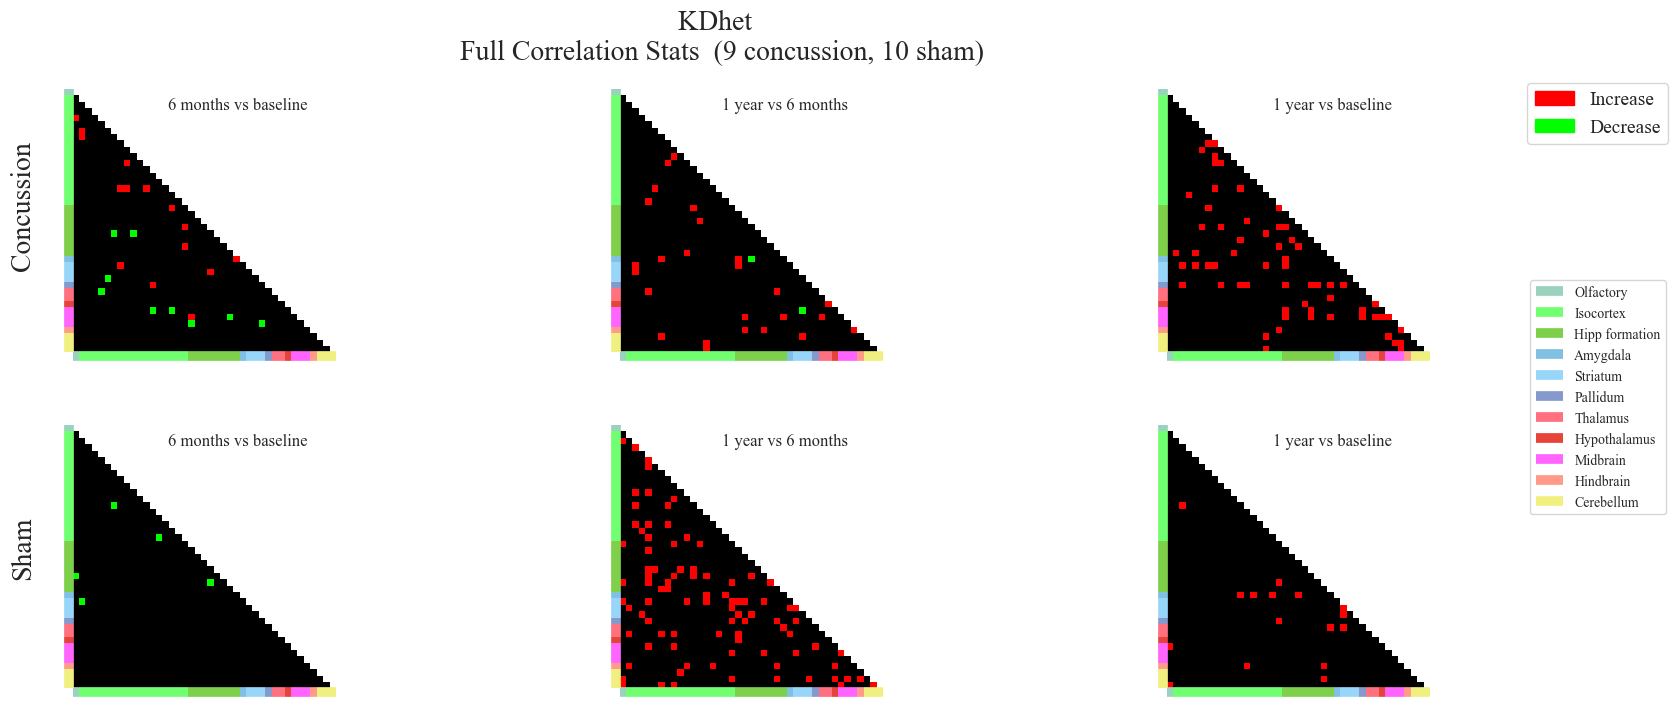

In [34]:

from nilearn import plotting
fig, axs = plt.subplots(2, 3, figsize=(20, 8))
fig.suptitle(f'KDhet \n Full Correlation Stats  (9 PBS, 10 PFF)', fontsize=20)
vmin_val = -1
vmax_val = 1
title_font = 12
title_y_pos = 0.9
title_x_pos = 0.65
cmap_black_red_green = ListedColormap(['#01ff00', 'black', '#ff0000'])
# [0,0]
stats_PBS_s1_vs_s2_fwep_c2 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PBS_s1_vs_s2_dat_tstat_fwep_c2.csv", delimiter=",")
stats_PBS_s1_vs_s2_fwep_c2 = (stats_PBS_s1_vs_s2_fwep_c2 < 0.05).astype(int)
stats_PBS_s1_vs_s2_fwep_c2 = connectome.vec_to_sym_matrix(stats_PBS_s1_vs_s2_fwep_c2, diagonal=np.zeros(no_roi))

stats_PBS_s1_vs_s2_fwep_c1 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PBS_s1_vs_s2_dat_tstat_fwep_c1.csv", delimiter=",")
stats_PBS_s1_vs_s2_fwep_c1 = (stats_PBS_s1_vs_s2_fwep_c1 < 0.05).astype(int)
stats_PBS_s1_vs_s2_fwep_c1 = connectome.vec_to_sym_matrix(stats_PBS_s1_vs_s2_fwep_c1, diagonal=np.zeros(no_roi))
stats_PBS_s1_vs_s2_fwep = stats_PBS_s1_vs_s2_fwep_c2 + stats_PBS_s1_vs_s2_fwep_c1 * -1

plot_unsym_conn_mat(
    axs[0, 0],
    stats_PBS_s1_vs_s2_fwep,
    regions_list=labels_12_list,
    # labels=labels_82,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    cmap=cmap_black_red_green,
    colorbar=False

)
axs[0, 0].set_title('6 months vs baseline', fontsize=title_font, y=title_y_pos, x=title_x_pos)
# axs[0, 0].text(103, 40,  'FDR p-value', fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')

# # [1,0]
stats_PFF_s1_vs_s2_fwep_c2 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PFF_s1_vs_s2_dat_tstat_fwep_c2.csv", delimiter=",")
stats_PFF_s1_vs_s2_fwep_c2 = (stats_PFF_s1_vs_s2_fwep_c2 < 0.05).astype(int)
stats_PFF_s1_vs_s2_fwep_c2 = connectome.vec_to_sym_matrix(stats_PFF_s1_vs_s2_fwep_c2, diagonal=np.zeros(no_roi))

stats_PFF_s1_vs_s2_fwep_c1 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PFF_s1_vs_s2_dat_tstat_fwep_c1.csv", delimiter=",")
stats_PFF_s1_vs_s2_fwep_c1 = (stats_PFF_s1_vs_s2_fwep_c1 < 0.05).astype(int)
stats_PFF_s1_vs_s2_fwep_c1 = connectome.vec_to_sym_matrix(stats_PFF_s1_vs_s2_fwep_c1, diagonal=np.zeros(no_roi))
stats_PFF_s1_vs_s2_fwep = stats_PFF_s1_vs_s2_fwep_c2 + stats_PFF_s1_vs_s2_fwep_c1 * -1

plot_unsym_conn_mat(
    axs[1, 0],
    stats_PFF_s1_vs_s2_fwep,
    regions_list=labels_12_list,
    # labels=labels_82,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    cmap=cmap_black_red_green,
    colorbar=False

)
axs[1, 0].set_title('6 months vs baseline', fontsize=title_font, y=title_y_pos, x=title_x_pos)
# axs[1, 0].text(103, 40,  'FDR p-value', fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')


# [0,2]
stats_PBS_s1_vs_s3_fwep_c2 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PBS_s1_vs_s3_dat_tstat_fwep_c2.csv", delimiter=",")
stats_PBS_s1_vs_s3_fwep_c2 = (stats_PBS_s1_vs_s3_fwep_c2 < 0.05).astype(int)
stats_PBS_s1_vs_s3_fwep_c2 = connectome.vec_to_sym_matrix(stats_PBS_s1_vs_s3_fwep_c2, diagonal=np.zeros(no_roi))

stats_PBS_s1_vs_s3_fwep_c1 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PBS_s1_vs_s3_dat_tstat_fwep_c1.csv", delimiter=",")
stats_PBS_s1_vs_s3_fwep_c1 = (stats_PBS_s1_vs_s3_fwep_c1 < 0.05).astype(int)
stats_PBS_s1_vs_s3_fwep_c1 = connectome.vec_to_sym_matrix(stats_PBS_s1_vs_s3_fwep_c1, diagonal=np.zeros(no_roi))
stats_PBS_s1_vs_s3_fwep = stats_PBS_s1_vs_s3_fwep_c2 + stats_PBS_s1_vs_s3_fwep_c1 * -1

plot_unsym_conn_mat(
    axs[0, 2],
    stats_PBS_s1_vs_s3_fwep,
    regions_list=labels_12_list,
    # labels=labels_82,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    cmap=cmap_black_red_green,
    colorbar=False

)
axs[0, 2].set_title('1 year vs baseline', fontsize=title_font, y=title_y_pos, x=title_x_pos)
# axs[0, 2].text(103, 40,  'FDR p-value', fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')

# [1,2]
stats_PFF_s1_vs_s3_fwep_c2 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PFF_s1_vs_s3_dat_tstat_fwep_c2.csv", delimiter=",")
stats_PFF_s1_vs_s3_fwep_c2 = (stats_PFF_s1_vs_s3_fwep_c2 < 0.05).astype(int)
stats_PFF_s1_vs_s3_fwep_c2 = connectome.vec_to_sym_matrix(stats_PFF_s1_vs_s3_fwep_c2, diagonal=np.zeros(no_roi))

stats_PFF_s1_vs_s3_fwep_c1 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PFF_s1_vs_s3_dat_tstat_fwep_c1.csv", delimiter=",")
stats_PFF_s1_vs_s3_fwep_c1 = (stats_PFF_s1_vs_s3_fwep_c1 < 0.05).astype(int)
stats_PFF_s1_vs_s3_fwep_c1 = connectome.vec_to_sym_matrix(stats_PFF_s1_vs_s3_fwep_c1, diagonal=np.zeros(no_roi))
stats_PFF_s1_vs_s3_fwep = stats_PFF_s1_vs_s3_fwep_c2 + stats_PFF_s1_vs_s3_fwep_c1 * -1

plot_unsym_conn_mat(
    axs[1, 2],
    stats_PFF_s1_vs_s3_fwep,
    regions_list=labels_12_list,
    # labels=labels_82,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    cmap=cmap_black_red_green,
    colorbar=False

)
axs[1, 2].set_title('1 year vs baseline', fontsize=title_font, y=title_y_pos, x=title_x_pos)
# axs[1, 2].text(103, 40,  'FDR p-value', fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')

# [0,1]
stats_PBS_s2_vs_s3_fwep_c2 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PBS_s2_vs_s3_dat_tstat_fwep_c2.csv", delimiter=",")
stats_PBS_s2_vs_s3_fwep_c2 = (stats_PBS_s2_vs_s3_fwep_c2 < 0.05).astype(int)
stats_PBS_s2_vs_s3_fwep_c2 = connectome.vec_to_sym_matrix(stats_PBS_s2_vs_s3_fwep_c2, diagonal=np.zeros(no_roi))

stats_PBS_s2_vs_s3_fwep_c1 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PBS_s2_vs_s3_dat_tstat_fwep_c1.csv", delimiter=",")
stats_PBS_s2_vs_s3_fwep_c1 = (stats_PBS_s2_vs_s3_fwep_c1 < 0.05).astype(int)
stats_PBS_s2_vs_s3_fwep_c1 = connectome.vec_to_sym_matrix(stats_PBS_s2_vs_s3_fwep_c1, diagonal=np.zeros(no_roi))
stats_PBS_s2_vs_s3_fwep = stats_PBS_s2_vs_s3_fwep_c2 + stats_PBS_s2_vs_s3_fwep_c1 * -1


plot_unsym_conn_mat(
    axs[0, 1],
    stats_PBS_s2_vs_s3_fwep,
    regions_list=labels_12_list,
    # labels=labels_82,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    cmap=cmap_black_red_green,
    colorbar=False

)
axs[0, 1].set_title('1 year vs 6 months', fontsize=title_font, y=title_y_pos, x=title_x_pos)
# axs[0, 1].text(103, 40,  'FDR p-value', fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')

# [1,1]
stats_PFF_s2_vs_s3_fwep_c2 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PFF_s2_vs_s3_dat_tstat_fwep_c2.csv", delimiter=",")
stats_PFF_s2_vs_s3_fwep_c2 = (stats_PFF_s2_vs_s3_fwep_c2 < 0.05).astype(int)
stats_PFF_s2_vs_s3_fwep_c2 = connectome.vec_to_sym_matrix(stats_PFF_s2_vs_s3_fwep_c2, diagonal=np.zeros(no_roi))

stats_PFF_s2_vs_s3_fwep_c1 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PFF_s2_vs_s3_dat_tstat_fwep_c1.csv", delimiter=",")
stats_PFF_s2_vs_s3_fwep_c1 = (stats_PFF_s2_vs_s3_fwep_c1 < 0.05).astype(int)
stats_PFF_s2_vs_s3_fwep_c1 = connectome.vec_to_sym_matrix(stats_PFF_s2_vs_s3_fwep_c1, diagonal=np.zeros(no_roi))
stats_PFF_s2_vs_s3_fwep = stats_PFF_s2_vs_s3_fwep_c2 + stats_PFF_s2_vs_s3_fwep_c1 * -1


plot_unsym_conn_mat(
    axs[1, 1],
    stats_PFF_s2_vs_s3_fwep,
    regions_list=labels_12_list,
    # labels=labels_82,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    cmap=cmap_black_red_green,
    colorbar=False

)
axs[1, 1].set_title('1 year vs 6 months', fontsize=title_font, y=title_y_pos, x=title_x_pos)
# axs[1, 1].text(103, 40,  'FDR p-value', fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')

for ax in axs.flat:
    ax.grid(False)
    # remove the horizontal and vertical lines around the matrix
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    ax.hlines(y=41.5, xmin=0, xmax=1, colors="#9AD2BD", linewidth=7, label="Olfactory", antialiased=True)
    ax.hlines(y=41.5, xmin=1, xmax=18, colors="#70FF71", linewidth=7, label="Isocortex", antialiased=True)
    ax.hlines(y=41.5, xmin=18, xmax=26, colors="#7ED04B", linewidth=7, label="Hipp formation", antialiased=True)
    ax.hlines(y=41.5, xmin=26, xmax=27, colors="#80C0E2", linewidth=7,label="Amygdala", antialiased=True)
    ax.hlines(y=41.5, xmin=27, xmax=30, colors="#98D6F9", linewidth=7, label="Striatum", antialiased=True)
    ax.hlines(y=41.5, xmin=30, xmax=31, colors="#8599CC", linewidth=7, label="Pallidum", antialiased=True)
    ax.hlines(y=41.5, xmin=31, xmax=33, colors="#FF7080", linewidth=7, label="Thalamus", antialiased=True)
    ax.hlines(y=41.5, xmin=33, xmax=34, colors="#E64438", linewidth=7, label="Hypothalamus", antialiased=True)
    ax.hlines(y=41.5, xmin=34, xmax=37, colors="#FF64FF", linewidth=7, label="Midbrain", antialiased=True)
    ax.hlines(y=41.5, xmin=37, xmax=38, colors="#FF9B88", linewidth=7, label="Hindbrain", antialiased=True)
    ax.hlines(y=41.5, xmin=38, xmax=41, colors="#F0F080", linewidth=7, label="Cerebellum", antialiased=True)
    #
    ax.vlines(x=-0.5, ymin=0, ymax=1, colors="#9AD2BD", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=1, ymax=18, colors="#70FF71", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=18, ymax=26, colors="#7ED04B", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=26, ymax=27, colors="#80C0E2", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=27, ymax=30, colors="#98D6F9", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=30, ymax=31, colors="#8599CC", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=31, ymax=33, colors="#FF7080", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=33, ymax=34, colors="#E64438", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=34, ymax=37, colors="#FF64FF", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=37, ymax=38, colors="#FF9B88", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=38, ymax=41, colors="#F0F080", linewidth=7, antialiased=True)
ax.legend(loc='center', bbox_to_anchor=(1.6, 1.1))
ax.text(-180,-25, "Concussion", fontsize=20, rotation=90)
ax.text(-180,23, "Sham", fontsize=20, rotation=90)

# Define legend patches
red_patch = mpatches.Patch(color='#ff0000', label='Increase')
green_patch = mpatches.Patch(color='#01ff00', label='Decrease')

# Add legend to the whole figure
fig.legend(handles=[red_patch, green_patch],
           loc='upper right',
           bbox_to_anchor=(0.98, 0.9),  # adjust position
           ncol=1,
           fontsize=14,
           frameon=True)

plt.savefig("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/Correlation_stats_c2_red_green.svg")
plt.savefig("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/Correlation_stats_c2_red_green.png")
plt.savefig("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/Correlation_stats_c2_red_green.pdf")
plt.show()

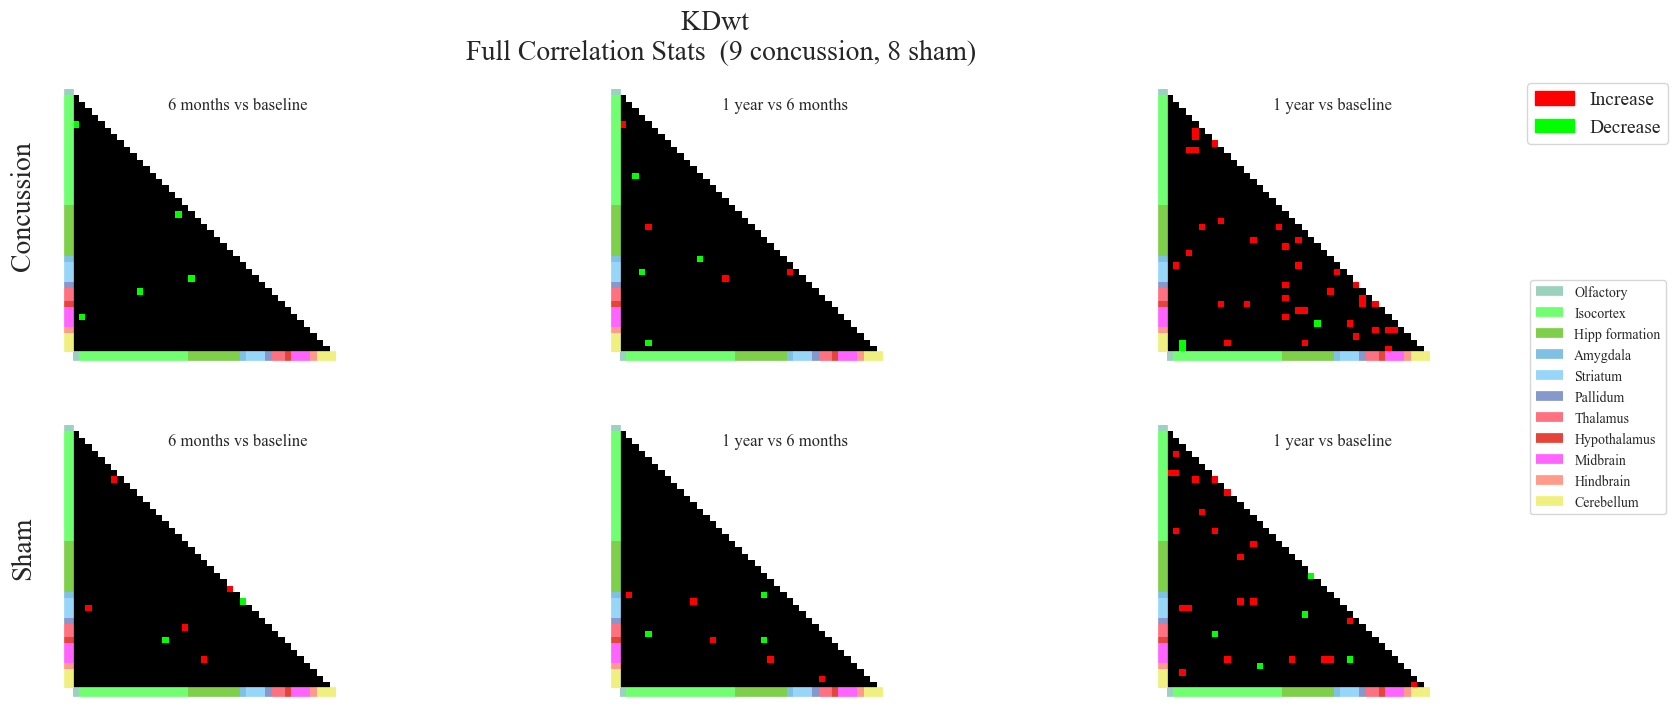

In [35]:

from nilearn import plotting
fig, axs = plt.subplots(2, 3, figsize=(20, 8))
fig.suptitle(f'KDwt \n Full Correlation Stats  (9 PBS, 8 PFF)', fontsize=20)
vmin_val = -1
vmax_val = 1
title_font = 12
title_y_pos = 0.9
title_x_pos = 0.65
cmap_black_red_green = ListedColormap(['#01ff00', 'black', '#ff0000'])
# [0,0]
stats_PBS_s1_vs_s2_fwep_c2 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_KDwt_FC_12_ROI/correlation/PBS_s1_vs_s2_dat_tstat_fwep_c2.csv", delimiter=",")
stats_PBS_s1_vs_s2_fwep_c2 = (stats_PBS_s1_vs_s2_fwep_c2 < 0.05).astype(int)
stats_PBS_s1_vs_s2_fwep_c2 = connectome.vec_to_sym_matrix(stats_PBS_s1_vs_s2_fwep_c2, diagonal=np.zeros(no_roi))

stats_PBS_s1_vs_s2_fwep_c1 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_KDwt_FC_12_ROI/correlation/PBS_s1_vs_s2_dat_tstat_fwep_c1.csv", delimiter=",")
stats_PBS_s1_vs_s2_fwep_c1 = (stats_PBS_s1_vs_s2_fwep_c1 < 0.05).astype(int)
stats_PBS_s1_vs_s2_fwep_c1 = connectome.vec_to_sym_matrix(stats_PBS_s1_vs_s2_fwep_c1, diagonal=np.zeros(no_roi))
stats_PBS_s1_vs_s2_fwep = stats_PBS_s1_vs_s2_fwep_c2 + stats_PBS_s1_vs_s2_fwep_c1 * -1

plot_unsym_conn_mat(
    axs[0, 0],
    stats_PBS_s1_vs_s2_fwep,
    regions_list=labels_12_list,
    # labels=labels_82,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    cmap=cmap_black_red_green,
    colorbar=False

)
axs[0, 0].set_title('6 months vs baseline', fontsize=title_font, y=title_y_pos, x=title_x_pos)
# axs[0, 0].text(103, 40,  'FDR p-value', fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')

# # [1,0]
stats_PFF_s1_vs_s2_fwep_c2 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_KDwt_FC_12_ROI/correlation/PFF_s1_vs_s2_dat_tstat_fwep_c2.csv", delimiter=",")
stats_PFF_s1_vs_s2_fwep_c2 = (stats_PFF_s1_vs_s2_fwep_c2 < 0.05).astype(int)
stats_PFF_s1_vs_s2_fwep_c2 = connectome.vec_to_sym_matrix(stats_PFF_s1_vs_s2_fwep_c2, diagonal=np.zeros(no_roi))

stats_PFF_s1_vs_s2_fwep_c1 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_KDwt_FC_12_ROI/correlation/PFF_s1_vs_s2_dat_tstat_fwep_c1.csv", delimiter=",")
stats_PFF_s1_vs_s2_fwep_c1 = (stats_PFF_s1_vs_s2_fwep_c1 < 0.05).astype(int)
stats_PFF_s1_vs_s2_fwep_c1 = connectome.vec_to_sym_matrix(stats_PFF_s1_vs_s2_fwep_c1, diagonal=np.zeros(no_roi))
stats_PFF_s1_vs_s2_fwep = stats_PFF_s1_vs_s2_fwep_c2 + stats_PFF_s1_vs_s2_fwep_c1 * -1

plot_unsym_conn_mat(
    axs[1, 0],
    stats_PFF_s1_vs_s2_fwep,
    regions_list=labels_12_list,
    # labels=labels_82,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    cmap=cmap_black_red_green,
    colorbar=False

)
axs[1, 0].set_title('6 months vs baseline', fontsize=title_font, y=title_y_pos, x=title_x_pos)
# axs[1, 0].text(103, 40,  'FDR p-value', fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')


# [0,2]
stats_PBS_s1_vs_s3_fwep_c2 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_KDwt_FC_12_ROI/correlation/PBS_s1_vs_s3_dat_tstat_fwep_c2.csv", delimiter=",")
stats_PBS_s1_vs_s3_fwep_c2 = (stats_PBS_s1_vs_s3_fwep_c2 < 0.05).astype(int)
stats_PBS_s1_vs_s3_fwep_c2 = connectome.vec_to_sym_matrix(stats_PBS_s1_vs_s3_fwep_c2, diagonal=np.zeros(no_roi))

stats_PBS_s1_vs_s3_fwep_c1 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_KDwt_FC_12_ROI/correlation/PBS_s1_vs_s3_dat_tstat_fwep_c1.csv", delimiter=",")
stats_PBS_s1_vs_s3_fwep_c1 = (stats_PBS_s1_vs_s3_fwep_c1 < 0.05).astype(int)
stats_PBS_s1_vs_s3_fwep_c1 = connectome.vec_to_sym_matrix(stats_PBS_s1_vs_s3_fwep_c1, diagonal=np.zeros(no_roi))
stats_PBS_s1_vs_s3_fwep = stats_PBS_s1_vs_s3_fwep_c2 + stats_PBS_s1_vs_s3_fwep_c1 * -1

plot_unsym_conn_mat(
    axs[0, 2],
    stats_PBS_s1_vs_s3_fwep,
    regions_list=labels_12_list,
    # labels=labels_82,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    cmap=cmap_black_red_green,
    colorbar=False

)
axs[0, 2].set_title('1 year vs baseline', fontsize=title_font, y=title_y_pos, x=title_x_pos)
# axs[0, 2].text(103, 40,  'FDR p-value', fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')

# [1,2]
stats_PFF_s1_vs_s3_fwep_c2 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_KDwt_FC_12_ROI/correlation/PFF_s1_vs_s3_dat_tstat_fwep_c2.csv", delimiter=",")
stats_PFF_s1_vs_s3_fwep_c2 = (stats_PFF_s1_vs_s3_fwep_c2 < 0.05).astype(int)
stats_PFF_s1_vs_s3_fwep_c2 = connectome.vec_to_sym_matrix(stats_PFF_s1_vs_s3_fwep_c2, diagonal=np.zeros(no_roi))

stats_PFF_s1_vs_s3_fwep_c1 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_KDwt_FC_12_ROI/correlation/PFF_s1_vs_s3_dat_tstat_fwep_c1.csv", delimiter=",")
stats_PFF_s1_vs_s3_fwep_c1 = (stats_PFF_s1_vs_s3_fwep_c1 < 0.05).astype(int)
stats_PFF_s1_vs_s3_fwep_c1 = connectome.vec_to_sym_matrix(stats_PFF_s1_vs_s3_fwep_c1, diagonal=np.zeros(no_roi))
stats_PFF_s1_vs_s3_fwep = stats_PFF_s1_vs_s3_fwep_c2 + stats_PFF_s1_vs_s3_fwep_c1 * -1

plot_unsym_conn_mat(
    axs[1, 2],
    stats_PFF_s1_vs_s3_fwep,
    regions_list=labels_12_list,
    # labels=labels_82,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    cmap=cmap_black_red_green,
    colorbar=False

)
axs[1, 2].set_title('1 year vs baseline', fontsize=title_font, y=title_y_pos, x=title_x_pos)
# axs[1, 2].text(103, 40,  'FDR p-value', fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')

# [0,1]
stats_PBS_s2_vs_s3_fwep_c2 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_KDwt_FC_12_ROI/correlation/PBS_s2_vs_s3_dat_tstat_fwep_c2.csv", delimiter=",")
stats_PBS_s2_vs_s3_fwep_c2 = (stats_PBS_s2_vs_s3_fwep_c2 < 0.05).astype(int)
stats_PBS_s2_vs_s3_fwep_c2 = connectome.vec_to_sym_matrix(stats_PBS_s2_vs_s3_fwep_c2, diagonal=np.zeros(no_roi))

stats_PBS_s2_vs_s3_fwep_c1 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_KDwt_FC_12_ROI/correlation/PBS_s2_vs_s3_dat_tstat_fwep_c1.csv", delimiter=",")
stats_PBS_s2_vs_s3_fwep_c1 = (stats_PBS_s2_vs_s3_fwep_c1 < 0.05).astype(int)
stats_PBS_s2_vs_s3_fwep_c1 = connectome.vec_to_sym_matrix(stats_PBS_s2_vs_s3_fwep_c1, diagonal=np.zeros(no_roi))
stats_PBS_s2_vs_s3_fwep = stats_PBS_s2_vs_s3_fwep_c2 + stats_PBS_s2_vs_s3_fwep_c1 * -1


plot_unsym_conn_mat(
    axs[0, 1],
    stats_PBS_s2_vs_s3_fwep,
    regions_list=labels_12_list,
    # labels=labels_82,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    cmap=cmap_black_red_green,
    colorbar=False

)
axs[0, 1].set_title('1 year vs 6 months', fontsize=title_font, y=title_y_pos, x=title_x_pos)
# axs[0, 1].text(103, 40,  'FDR p-value', fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')

# [1,1]
stats_PFF_s2_vs_s3_fwep_c2 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_KDwt_FC_12_ROI/correlation/PFF_s2_vs_s3_dat_tstat_fwep_c2.csv", delimiter=",")
stats_PFF_s2_vs_s3_fwep_c2 = (stats_PFF_s2_vs_s3_fwep_c2 < 0.05).astype(int)
stats_PFF_s2_vs_s3_fwep_c2 = connectome.vec_to_sym_matrix(stats_PFF_s2_vs_s3_fwep_c2, diagonal=np.zeros(no_roi))

stats_PFF_s2_vs_s3_fwep_c1 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_KDwt_FC_12_ROI/correlation/PFF_s2_vs_s3_dat_tstat_fwep_c1.csv", delimiter=",")
stats_PFF_s2_vs_s3_fwep_c1 = (stats_PFF_s2_vs_s3_fwep_c1 < 0.05).astype(int)
stats_PFF_s2_vs_s3_fwep_c1 = connectome.vec_to_sym_matrix(stats_PFF_s2_vs_s3_fwep_c1, diagonal=np.zeros(no_roi))
stats_PFF_s2_vs_s3_fwep = stats_PFF_s2_vs_s3_fwep_c2 + stats_PFF_s2_vs_s3_fwep_c1 * -1


plot_unsym_conn_mat(
    axs[1, 1],
    stats_PFF_s2_vs_s3_fwep,
    regions_list=labels_12_list,
    # labels=labels_82,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    cmap=cmap_black_red_green,
    colorbar=False

)
axs[1, 1].set_title('1 year vs 6 months', fontsize=title_font, y=title_y_pos, x=title_x_pos)
# axs[1, 1].text(103, 40,  'FDR p-value', fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')

for ax in axs.flat:
    ax.grid(False)
    # remove the horizontal and vertical lines around the matrix
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    ax.hlines(y=41.5, xmin=0, xmax=1, colors="#9AD2BD", linewidth=7, label="Olfactory", antialiased=True)
    ax.hlines(y=41.5, xmin=1, xmax=18, colors="#70FF71", linewidth=7, label="Isocortex", antialiased=True)
    ax.hlines(y=41.5, xmin=18, xmax=26, colors="#7ED04B", linewidth=7, label="Hipp formation", antialiased=True)
    ax.hlines(y=41.5, xmin=26, xmax=27, colors="#80C0E2", linewidth=7,label="Amygdala", antialiased=True)
    ax.hlines(y=41.5, xmin=27, xmax=30, colors="#98D6F9", linewidth=7, label="Striatum", antialiased=True)
    ax.hlines(y=41.5, xmin=30, xmax=31, colors="#8599CC", linewidth=7, label="Pallidum", antialiased=True)
    ax.hlines(y=41.5, xmin=31, xmax=33, colors="#FF7080", linewidth=7, label="Thalamus", antialiased=True)
    ax.hlines(y=41.5, xmin=33, xmax=34, colors="#E64438", linewidth=7, label="Hypothalamus", antialiased=True)
    ax.hlines(y=41.5, xmin=34, xmax=37, colors="#FF64FF", linewidth=7, label="Midbrain", antialiased=True)
    ax.hlines(y=41.5, xmin=37, xmax=38, colors="#FF9B88", linewidth=7, label="Hindbrain", antialiased=True)
    ax.hlines(y=41.5, xmin=38, xmax=41, colors="#F0F080", linewidth=7, label="Cerebellum", antialiased=True)
    #
    ax.vlines(x=-0.5, ymin=0, ymax=1, colors="#9AD2BD", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=1, ymax=18, colors="#70FF71", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=18, ymax=26, colors="#7ED04B", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=26, ymax=27, colors="#80C0E2", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=27, ymax=30, colors="#98D6F9", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=30, ymax=31, colors="#8599CC", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=31, ymax=33, colors="#FF7080", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=33, ymax=34, colors="#E64438", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=34, ymax=37, colors="#FF64FF", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=37, ymax=38, colors="#FF9B88", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=38, ymax=41, colors="#F0F080", linewidth=7, antialiased=True)
ax.legend(loc='center', bbox_to_anchor=(1.6, 1.1))
ax.text(-180,-25, "Concussion", fontsize=20, rotation=90)
ax.text(-180,23, "Sham", fontsize=20, rotation=90)


# Define legend patches
red_patch = mpatches.Patch(color='#ff0000', label='Increase')
green_patch = mpatches.Patch(color='#01ff00', label='Decrease')

# Add legend to the whole figure
fig.legend(handles=[red_patch, green_patch],
           loc='upper right',
           bbox_to_anchor=(0.98, 0.9),  # adjust position
           ncol=1,
           fontsize=14,
           frameon=True)
plt.savefig("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_KDwt_FC_12_ROI/correlation/Correlation_stats_c2_red_green.svg")
plt.savefig("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_KDwt_FC_12_ROI/correlation/Correlation_stats_c2_red_green.png")
plt.savefig("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_KDwt_FC_12_ROI/correlation/Correlation_stats_c2_red_green.pdf")
plt.show()

# <font color="red">=======================binarize the differneces by clipped % change ============================

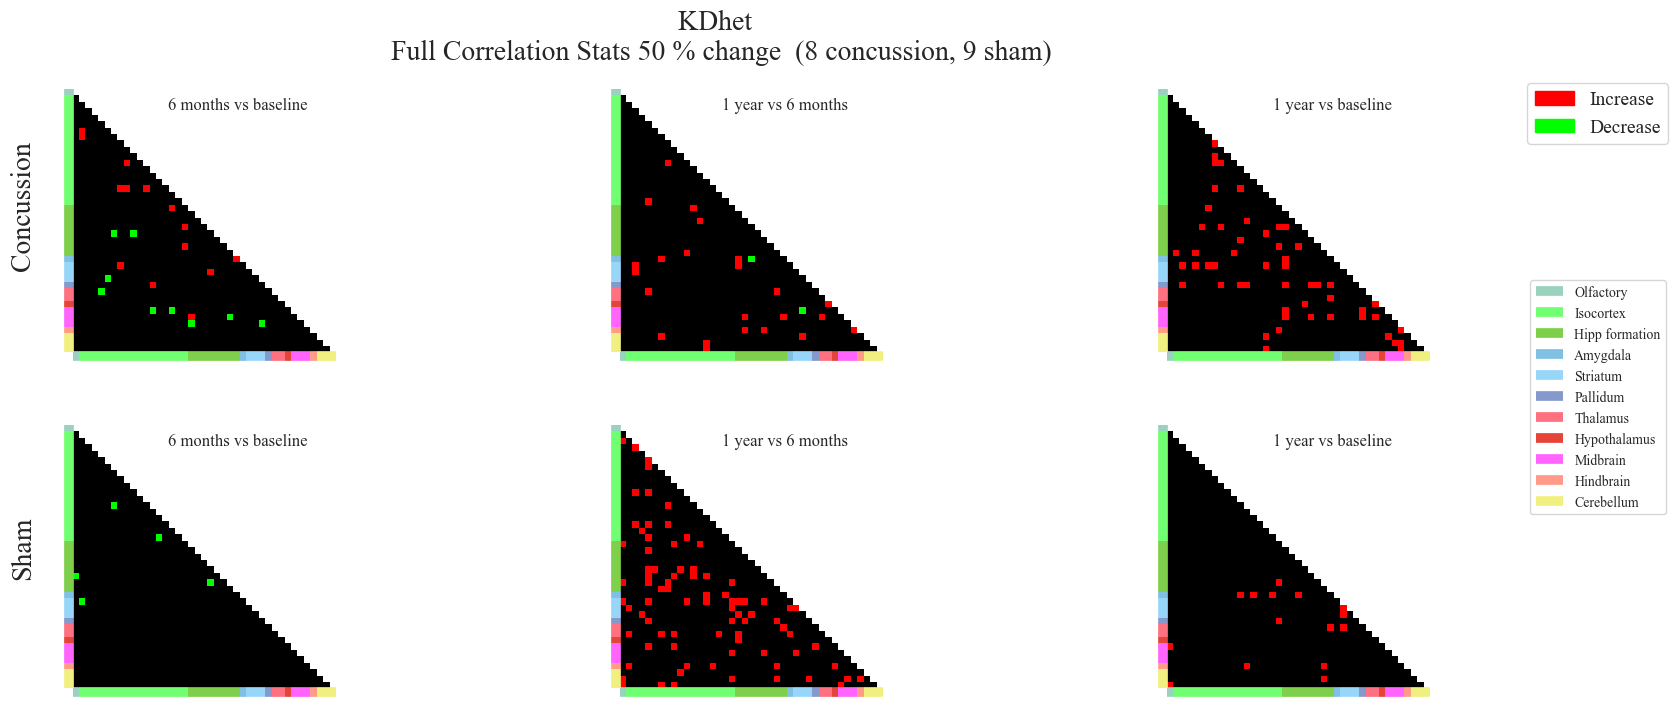

In [36]:

from nilearn import plotting
change_perc = 50
fig, axs = plt.subplots(2, 3, figsize=(20, 8))
fig.suptitle(f'KDhet \n Full Correlation Stats {change_perc} % change  ({KDhet_PBS_n_subjects} PBS, {KDhet_PFF_n_subjects} PFF)', fontsize=20)
vmin_val = -1
vmax_val = 1
title_font = 12
title_y_pos = 0.9
title_x_pos = 0.65


cmap_black_red_green = ListedColormap(['#01ff00', 'black', '#ff0000'])
# ==========================================================================================================================================================================================
# [0,0]
stats_PBS_s1_vs_s2_fwep_c2 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PBS_s1_vs_s2_dat_tstat_fwep_c2.csv", delimiter=",")
stats_PBS_s1_vs_s2_fwep_c2 = (stats_PBS_s1_vs_s2_fwep_c2 < 0.05).astype(int)
stats_PBS_s1_vs_s2_fwep_c2 = connectome.vec_to_sym_matrix(stats_PBS_s1_vs_s2_fwep_c2, diagonal=np.zeros(no_roi))

stats_PBS_s1_vs_s2_fwep_c1 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PBS_s1_vs_s2_dat_tstat_fwep_c1.csv", delimiter=",")
stats_PBS_s1_vs_s2_fwep_c1 = (stats_PBS_s1_vs_s2_fwep_c1 < 0.05).astype(int)
stats_PBS_s1_vs_s2_fwep_c1 = connectome.vec_to_sym_matrix(stats_PBS_s1_vs_s2_fwep_c1, diagonal=np.zeros(no_roi))
stats_PBS_s1_vs_s2_fwep = stats_PBS_s1_vs_s2_fwep_c2 + stats_PBS_s1_vs_s2_fwep_c1 * -1


mask = (
    (PBS_s2_vs_s1_correlation_KDhet > change_perc) |
    (PBS_s2_vs_s1_correlation_KDhet < -change_perc)
).astype(int)

plot_unsym_conn_mat(
    axs[0, 0],
    stats_PBS_s1_vs_s2_fwep * mask,
    regions_list=labels_12_list,
    # labels=labels_82,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    cmap=cmap_black_red_green,
    colorbar=False

)
axs[0, 0].set_title('6 months vs baseline', fontsize=title_font, y=title_y_pos, x=title_x_pos)
# axs[0, 0].text(103, 40,  'FDR p-value', fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')
# ==========================================================================================================================================================================================
# # [1,0]
stats_PFF_s1_vs_s2_fwep_c2 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PFF_s1_vs_s2_dat_tstat_fwep_c2.csv", delimiter=",")
stats_PFF_s1_vs_s2_fwep_c2 = (stats_PFF_s1_vs_s2_fwep_c2 < 0.05).astype(int)
stats_PFF_s1_vs_s2_fwep_c2 = connectome.vec_to_sym_matrix(stats_PFF_s1_vs_s2_fwep_c2, diagonal=np.zeros(no_roi))

stats_PFF_s1_vs_s2_fwep_c1 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PFF_s1_vs_s2_dat_tstat_fwep_c1.csv", delimiter=",")
stats_PFF_s1_vs_s2_fwep_c1 = (stats_PFF_s1_vs_s2_fwep_c1 < 0.05).astype(int)
stats_PFF_s1_vs_s2_fwep_c1 = connectome.vec_to_sym_matrix(stats_PFF_s1_vs_s2_fwep_c1, diagonal=np.zeros(no_roi))
stats_PFF_s1_vs_s2_fwep = stats_PFF_s1_vs_s2_fwep_c2 + stats_PFF_s1_vs_s2_fwep_c1 * -1

mask = (
    (PFF_s2_vs_s1_correlation_KDhet > change_perc) |
    (PFF_s2_vs_s1_correlation_KDhet < -change_perc)
).astype(int)

plot_unsym_conn_mat(
    axs[1, 0],
    stats_PFF_s1_vs_s2_fwep * mask,
    regions_list=labels_12_list,
    # labels=labels_82,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    cmap=cmap_black_red_green,
    colorbar=False

)
axs[1, 0].set_title('6 months vs baseline', fontsize=title_font, y=title_y_pos, x=title_x_pos)
# axs[1, 0].text(103, 40,  'FDR p-value', fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')

# ==========================================================================================================================================================================================
# [0,2]
stats_PBS_s1_vs_s3_fwep_c2 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PBS_s1_vs_s3_dat_tstat_fwep_c2.csv", delimiter=",")
stats_PBS_s1_vs_s3_fwep_c2 = (stats_PBS_s1_vs_s3_fwep_c2 < 0.05).astype(int)
stats_PBS_s1_vs_s3_fwep_c2 = connectome.vec_to_sym_matrix(stats_PBS_s1_vs_s3_fwep_c2, diagonal=np.zeros(no_roi))

stats_PBS_s1_vs_s3_fwep_c1 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PBS_s1_vs_s3_dat_tstat_fwep_c1.csv", delimiter=",")
stats_PBS_s1_vs_s3_fwep_c1 = (stats_PBS_s1_vs_s3_fwep_c1 < 0.05).astype(int)
stats_PBS_s1_vs_s3_fwep_c1 = connectome.vec_to_sym_matrix(stats_PBS_s1_vs_s3_fwep_c1, diagonal=np.zeros(no_roi))
stats_PBS_s1_vs_s3_fwep = stats_PBS_s1_vs_s3_fwep_c2 + stats_PBS_s1_vs_s3_fwep_c1 * -1

mask = (
    (PBS_s3_vs_s1_correlation_KDhet > change_perc) |
    (PBS_s3_vs_s1_correlation_KDhet < -change_perc)
).astype(int)

plot_unsym_conn_mat(
    axs[0, 2],
    stats_PBS_s1_vs_s3_fwep * mask,
    regions_list=labels_12_list,
    # labels=labels_82,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    cmap=cmap_black_red_green,
    colorbar=False

)
axs[0, 2].set_title('1 year vs baseline', fontsize=title_font, y=title_y_pos, x=title_x_pos)
# axs[0, 2].text(103, 40,  'FDR p-value', fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')
# ==========================================================================================================================================================================================
# [1,2]
stats_PFF_s1_vs_s3_fwep_c2 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PFF_s1_vs_s3_dat_tstat_fwep_c2.csv", delimiter=",")
stats_PFF_s1_vs_s3_fwep_c2 = (stats_PFF_s1_vs_s3_fwep_c2 < 0.05).astype(int)
stats_PFF_s1_vs_s3_fwep_c2 = connectome.vec_to_sym_matrix(stats_PFF_s1_vs_s3_fwep_c2, diagonal=np.zeros(no_roi))

stats_PFF_s1_vs_s3_fwep_c1 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PFF_s1_vs_s3_dat_tstat_fwep_c1.csv", delimiter=",")
stats_PFF_s1_vs_s3_fwep_c1 = (stats_PFF_s1_vs_s3_fwep_c1 < 0.05).astype(int)
stats_PFF_s1_vs_s3_fwep_c1 = connectome.vec_to_sym_matrix(stats_PFF_s1_vs_s3_fwep_c1, diagonal=np.zeros(no_roi))
stats_PFF_s1_vs_s3_fwep = stats_PFF_s1_vs_s3_fwep_c2 + stats_PFF_s1_vs_s3_fwep_c1 * -1

mask = (
    (PFF_s3_vs_s1_correlation_KDhet > change_perc) |
    (PFF_s3_vs_s1_correlation_KDhet < -change_perc)
).astype(int)


plot_unsym_conn_mat(
    axs[1, 2],
    stats_PFF_s1_vs_s3_fwep * mask,
    regions_list=labels_12_list,
    # labels=labels_82,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    cmap=cmap_black_red_green,
    colorbar=False

)
axs[1, 2].set_title('1 year vs baseline', fontsize=title_font, y=title_y_pos, x=title_x_pos)
# axs[1, 2].text(103, 40,  'FDR p-value', fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')
# ==========================================================================================================================================================================================
# [0,1]
stats_PBS_s2_vs_s3_fwep_c2 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PBS_s2_vs_s3_dat_tstat_fwep_c2.csv", delimiter=",")
stats_PBS_s2_vs_s3_fwep_c2 = (stats_PBS_s2_vs_s3_fwep_c2 < 0.05).astype(int)
stats_PBS_s2_vs_s3_fwep_c2 = connectome.vec_to_sym_matrix(stats_PBS_s2_vs_s3_fwep_c2, diagonal=np.zeros(no_roi))

stats_PBS_s2_vs_s3_fwep_c1 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PBS_s2_vs_s3_dat_tstat_fwep_c1.csv", delimiter=",")
stats_PBS_s2_vs_s3_fwep_c1 = (stats_PBS_s2_vs_s3_fwep_c1 < 0.05).astype(int)
stats_PBS_s2_vs_s3_fwep_c1 = connectome.vec_to_sym_matrix(stats_PBS_s2_vs_s3_fwep_c1, diagonal=np.zeros(no_roi))
stats_PBS_s2_vs_s3_fwep = stats_PBS_s2_vs_s3_fwep_c2 + stats_PBS_s2_vs_s3_fwep_c1 * -1

mask = (
    (PBS_s3_vs_s2_correlation_KDhet > change_perc) |
    (PBS_s3_vs_s2_correlation_KDhet < -change_perc)
).astype(int)


plot_unsym_conn_mat(
    axs[0, 1],
    stats_PBS_s2_vs_s3_fwep * mask,
    regions_list=labels_12_list,
    # labels=labels_82,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    cmap=cmap_black_red_green,
    colorbar=False

)
axs[0, 1].set_title('1 year vs 6 months', fontsize=title_font, y=title_y_pos, x=title_x_pos)
# axs[0, 1].text(103, 40,  'FDR p-value', fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')
# ==========================================================================================================================================================================================
# [1,1]
stats_PFF_s2_vs_s3_fwep_c2 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PFF_s2_vs_s3_dat_tstat_fwep_c2.csv", delimiter=",")
stats_PFF_s2_vs_s3_fwep_c2 = (stats_PFF_s2_vs_s3_fwep_c2 < 0.05).astype(int)
stats_PFF_s2_vs_s3_fwep_c2 = connectome.vec_to_sym_matrix(stats_PFF_s2_vs_s3_fwep_c2, diagonal=np.zeros(no_roi))

stats_PFF_s2_vs_s3_fwep_c1 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/PFF_s2_vs_s3_dat_tstat_fwep_c1.csv", delimiter=",")
stats_PFF_s2_vs_s3_fwep_c1 = (stats_PFF_s2_vs_s3_fwep_c1 < 0.05).astype(int)
stats_PFF_s2_vs_s3_fwep_c1 = connectome.vec_to_sym_matrix(stats_PFF_s2_vs_s3_fwep_c1, diagonal=np.zeros(no_roi))
stats_PFF_s2_vs_s3_fwep = stats_PFF_s2_vs_s3_fwep_c2 + stats_PFF_s2_vs_s3_fwep_c1 * -1

mask = (
    (PFF_s3_vs_s2_correlation_KDhet > change_perc) |
    (PFF_s3_vs_s2_correlation_KDhet < -change_perc)
).astype(int)

plot_unsym_conn_mat(
    axs[1, 1],
    stats_PFF_s2_vs_s3_fwep * mask,
    regions_list=labels_12_list,
    # labels=labels_82,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    cmap=cmap_black_red_green,
    colorbar=False

)
axs[1, 1].set_title('1 year vs 6 months', fontsize=title_font, y=title_y_pos, x=title_x_pos)
# axs[1, 1].text(103, 40,  'FDR p-value', fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')
# ==========================================================================================================================================================================================
for ax in axs.flat:
    ax.grid(False)
    # remove the horizontal and vertical lines around the matrix
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    ax.hlines(y=41.5, xmin=0, xmax=1, colors="#9AD2BD", linewidth=7, label="Olfactory", antialiased=True)
    ax.hlines(y=41.5, xmin=1, xmax=18, colors="#70FF71", linewidth=7, label="Isocortex", antialiased=True)
    ax.hlines(y=41.5, xmin=18, xmax=26, colors="#7ED04B", linewidth=7, label="Hipp formation", antialiased=True)
    ax.hlines(y=41.5, xmin=26, xmax=27, colors="#80C0E2", linewidth=7,label="Amygdala", antialiased=True)
    ax.hlines(y=41.5, xmin=27, xmax=30, colors="#98D6F9", linewidth=7, label="Striatum", antialiased=True)
    ax.hlines(y=41.5, xmin=30, xmax=31, colors="#8599CC", linewidth=7, label="Pallidum", antialiased=True)
    ax.hlines(y=41.5, xmin=31, xmax=33, colors="#FF7080", linewidth=7, label="Thalamus", antialiased=True)
    ax.hlines(y=41.5, xmin=33, xmax=34, colors="#E64438", linewidth=7, label="Hypothalamus", antialiased=True)
    ax.hlines(y=41.5, xmin=34, xmax=37, colors="#FF64FF", linewidth=7, label="Midbrain", antialiased=True)
    ax.hlines(y=41.5, xmin=37, xmax=38, colors="#FF9B88", linewidth=7, label="Hindbrain", antialiased=True)
    ax.hlines(y=41.5, xmin=38, xmax=41, colors="#F0F080", linewidth=7, label="Cerebellum", antialiased=True)
    #
    ax.vlines(x=-0.5, ymin=0, ymax=1, colors="#9AD2BD", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=1, ymax=18, colors="#70FF71", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=18, ymax=26, colors="#7ED04B", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=26, ymax=27, colors="#80C0E2", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=27, ymax=30, colors="#98D6F9", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=30, ymax=31, colors="#8599CC", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=31, ymax=33, colors="#FF7080", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=33, ymax=34, colors="#E64438", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=34, ymax=37, colors="#FF64FF", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=37, ymax=38, colors="#FF9B88", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=38, ymax=41, colors="#F0F080", linewidth=7, antialiased=True)
ax.legend(loc='center', bbox_to_anchor=(1.6, 1.1))
ax.text(-180,-25, "Concussion", fontsize=20, rotation=90)
ax.text(-180,23, "Sham", fontsize=20, rotation=90)

# Define legend patches
red_patch = mpatches.Patch(color='#ff0000', label='Increase')
green_patch = mpatches.Patch(color='#01ff00', label='Decrease')

# Add legend to the whole figure
fig.legend(handles=[red_patch, green_patch],
           loc='upper right',
           bbox_to_anchor=(0.98, 0.9),  # adjust position
           ncol=1,
           fontsize=14,
           frameon=True)

plt.savefig("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/Correlation_stats_c2_red_green_binarized_change.svg")
plt.savefig("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/Correlation_stats_c2_red_green_binarized_change.png")
plt.savefig("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_FC_12_ROI/correlation/Correlation_stats_c2_red_green_binarized_change.pdf")
plt.show()


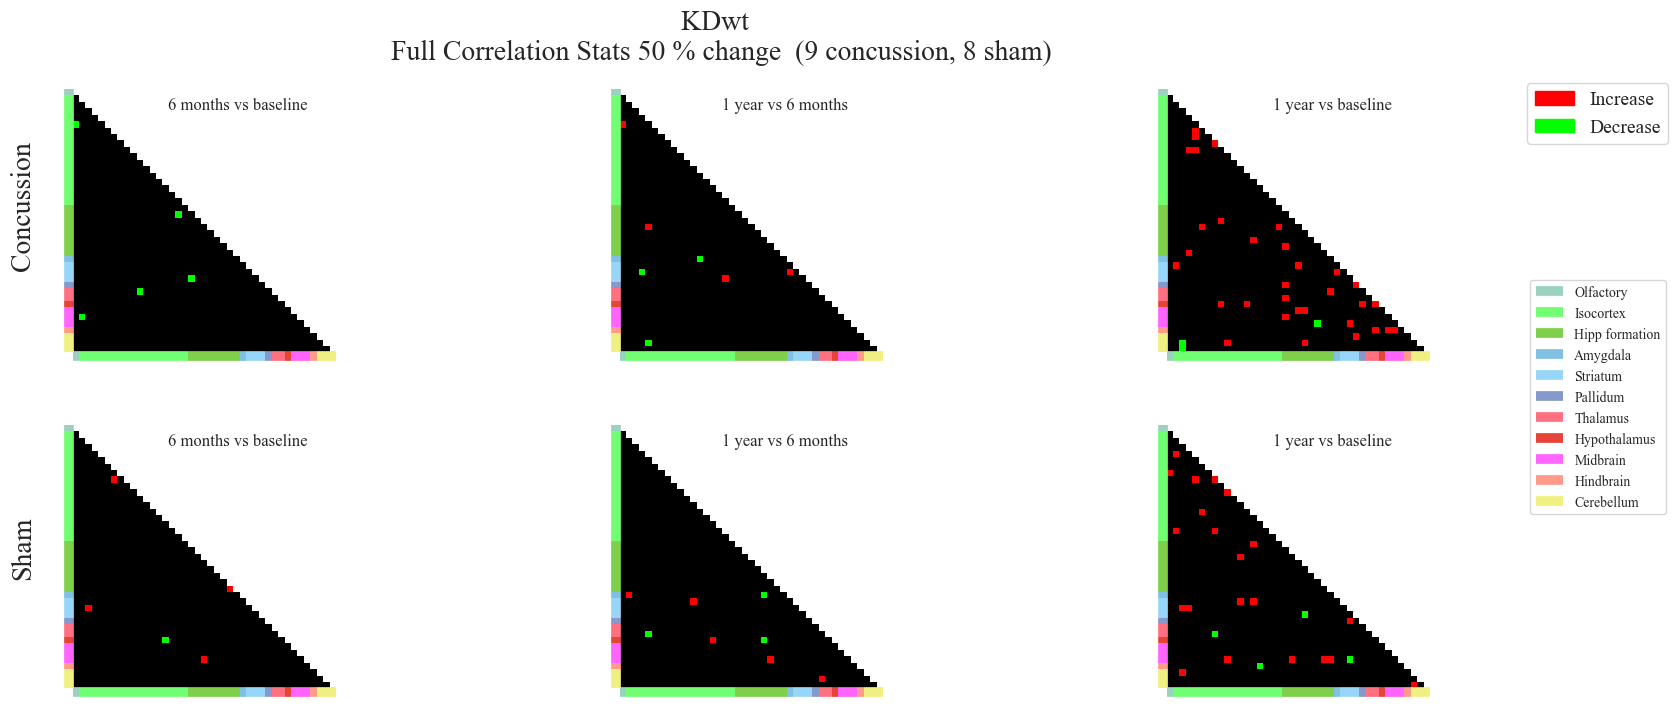

In [37]:

from nilearn import plotting
change_perc = 50
fig, axs = plt.subplots(2, 3, figsize=(20, 8))
fig.suptitle(f'KDwt \n Full Correlation Stats {change_perc} % change  (9 PBS, 8 PFF)', fontsize=20)
vmin_val = -1
vmax_val = 1
title_font = 12
title_y_pos = 0.9
title_x_pos = 0.65


cmap_black_red_green = ListedColormap(['#01ff00', 'black', '#ff0000'])
# ==========================================================================================================================================================================================
# [0,0]
stats_PBS_s1_vs_s2_fwep_c2 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_KDwt_FC_12_ROI/correlation/PBS_s1_vs_s2_dat_tstat_fwep_c2.csv", delimiter=",")
stats_PBS_s1_vs_s2_fwep_c2 = (stats_PBS_s1_vs_s2_fwep_c2 < 0.05).astype(int)
stats_PBS_s1_vs_s2_fwep_c2 = connectome.vec_to_sym_matrix(stats_PBS_s1_vs_s2_fwep_c2, diagonal=np.zeros(no_roi))

stats_PBS_s1_vs_s2_fwep_c1 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_KDwt_FC_12_ROI/correlation/PBS_s1_vs_s2_dat_tstat_fwep_c1.csv", delimiter=",")
stats_PBS_s1_vs_s2_fwep_c1 = (stats_PBS_s1_vs_s2_fwep_c1 < 0.05).astype(int)
stats_PBS_s1_vs_s2_fwep_c1 = connectome.vec_to_sym_matrix(stats_PBS_s1_vs_s2_fwep_c1, diagonal=np.zeros(no_roi))
stats_PBS_s1_vs_s2_fwep = stats_PBS_s1_vs_s2_fwep_c2 + stats_PBS_s1_vs_s2_fwep_c1 * -1


mask = (
    (PBS_s2_vs_s1_correlation_KDwt > change_perc) |
    (PBS_s2_vs_s1_correlation_KDwt < -change_perc)
).astype(int)

plot_unsym_conn_mat(
    axs[0, 0],
    stats_PBS_s1_vs_s2_fwep * mask,
    regions_list=labels_12_list,
    # labels=labels_82,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    cmap=cmap_black_red_green,
    colorbar=False

)
axs[0, 0].set_title('6 months vs baseline', fontsize=title_font, y=title_y_pos, x=title_x_pos)
# axs[0, 0].text(103, 40,  'FDR p-value', fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')
# ==========================================================================================================================================================================================
# # [1,0]
stats_PFF_s1_vs_s2_fwep_c2 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_KDwt_FC_12_ROI/correlation/PFF_s1_vs_s2_dat_tstat_fwep_c2.csv", delimiter=",")
stats_PFF_s1_vs_s2_fwep_c2 = (stats_PFF_s1_vs_s2_fwep_c2 < 0.05).astype(int)
stats_PFF_s1_vs_s2_fwep_c2 = connectome.vec_to_sym_matrix(stats_PFF_s1_vs_s2_fwep_c2, diagonal=np.zeros(no_roi))

stats_PFF_s1_vs_s2_fwep_c1 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_KDwt_FC_12_ROI/correlation/PFF_s1_vs_s2_dat_tstat_fwep_c1.csv", delimiter=",")
stats_PFF_s1_vs_s2_fwep_c1 = (stats_PFF_s1_vs_s2_fwep_c1 < 0.05).astype(int)
stats_PFF_s1_vs_s2_fwep_c1 = connectome.vec_to_sym_matrix(stats_PFF_s1_vs_s2_fwep_c1, diagonal=np.zeros(no_roi))
stats_PFF_s1_vs_s2_fwep = stats_PFF_s1_vs_s2_fwep_c2 + stats_PFF_s1_vs_s2_fwep_c1 * -1

mask = (
    (PFF_s2_vs_s1_correlation_KDwt > change_perc) |
    (PFF_s2_vs_s1_correlation_KDwt < -change_perc)
).astype(int)

plot_unsym_conn_mat(
    axs[1, 0],
    stats_PFF_s1_vs_s2_fwep * mask,
    regions_list=labels_12_list,
    # labels=labels_82,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    cmap=cmap_black_red_green,
    colorbar=False

)
axs[1, 0].set_title('6 months vs baseline', fontsize=title_font, y=title_y_pos, x=title_x_pos)
# axs[1, 0].text(103, 40,  'FDR p-value', fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')

# ==========================================================================================================================================================================================
# [0,2]
stats_PBS_s1_vs_s3_fwep_c2 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_KDwt_FC_12_ROI/correlation/PBS_s1_vs_s3_dat_tstat_fwep_c2.csv", delimiter=",")
stats_PBS_s1_vs_s3_fwep_c2 = (stats_PBS_s1_vs_s3_fwep_c2 < 0.05).astype(int)
stats_PBS_s1_vs_s3_fwep_c2 = connectome.vec_to_sym_matrix(stats_PBS_s1_vs_s3_fwep_c2, diagonal=np.zeros(no_roi))

stats_PBS_s1_vs_s3_fwep_c1 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_KDwt_FC_12_ROI/correlation/PBS_s1_vs_s3_dat_tstat_fwep_c1.csv", delimiter=",")
stats_PBS_s1_vs_s3_fwep_c1 = (stats_PBS_s1_vs_s3_fwep_c1 < 0.05).astype(int)
stats_PBS_s1_vs_s3_fwep_c1 = connectome.vec_to_sym_matrix(stats_PBS_s1_vs_s3_fwep_c1, diagonal=np.zeros(no_roi))
stats_PBS_s1_vs_s3_fwep = stats_PBS_s1_vs_s3_fwep_c2 + stats_PBS_s1_vs_s3_fwep_c1 * -1

mask = (
    (PBS_s3_vs_s1_correlation_KDwt > change_perc) |
    (PBS_s3_vs_s1_correlation_KDwt < -change_perc)
).astype(int)

plot_unsym_conn_mat(
    axs[0, 2],
    stats_PBS_s1_vs_s3_fwep * mask,
    regions_list=labels_12_list,
    # labels=labels_82,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    cmap=cmap_black_red_green,
    colorbar=False

)
axs[0, 2].set_title('1 year vs baseline', fontsize=title_font, y=title_y_pos, x=title_x_pos)
# axs[0, 2].text(103, 40,  'FDR p-value', fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')
# ==========================================================================================================================================================================================
# [1,2]
stats_PFF_s1_vs_s3_fwep_c2 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_KDwt_FC_12_ROI/correlation/PFF_s1_vs_s3_dat_tstat_fwep_c2.csv", delimiter=",")
stats_PFF_s1_vs_s3_fwep_c2 = (stats_PFF_s1_vs_s3_fwep_c2 < 0.05).astype(int)
stats_PFF_s1_vs_s3_fwep_c2 = connectome.vec_to_sym_matrix(stats_PFF_s1_vs_s3_fwep_c2, diagonal=np.zeros(no_roi))

stats_PFF_s1_vs_s3_fwep_c1 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_KDwt_FC_12_ROI/correlation/PFF_s1_vs_s3_dat_tstat_fwep_c1.csv", delimiter=",")
stats_PFF_s1_vs_s3_fwep_c1 = (stats_PFF_s1_vs_s3_fwep_c1 < 0.05).astype(int)
stats_PFF_s1_vs_s3_fwep_c1 = connectome.vec_to_sym_matrix(stats_PFF_s1_vs_s3_fwep_c1, diagonal=np.zeros(no_roi))
stats_PFF_s1_vs_s3_fwep = stats_PFF_s1_vs_s3_fwep_c2 + stats_PFF_s1_vs_s3_fwep_c1 * -1

mask = (
    (PFF_s3_vs_s1_correlation_KDwt > change_perc) |
    (PFF_s3_vs_s1_correlation_KDwt < -change_perc)
).astype(int)


plot_unsym_conn_mat(
    axs[1, 2],
    stats_PFF_s1_vs_s3_fwep * mask,
    regions_list=labels_12_list,
    # labels=labels_82,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    cmap=cmap_black_red_green,
    colorbar=False

)
axs[1, 2].set_title('1 year vs baseline', fontsize=title_font, y=title_y_pos, x=title_x_pos)
# axs[1, 2].text(103, 40,  'FDR p-value', fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')
# ==========================================================================================================================================================================================
# [0,1]
stats_PBS_s2_vs_s3_fwep_c2 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_KDwt_FC_12_ROI/correlation/PBS_s2_vs_s3_dat_tstat_fwep_c2.csv", delimiter=",")
stats_PBS_s2_vs_s3_fwep_c2 = (stats_PBS_s2_vs_s3_fwep_c2 < 0.05).astype(int)
stats_PBS_s2_vs_s3_fwep_c2 = connectome.vec_to_sym_matrix(stats_PBS_s2_vs_s3_fwep_c2, diagonal=np.zeros(no_roi))

stats_PBS_s2_vs_s3_fwep_c1 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_KDwt_FC_12_ROI/correlation/PBS_s2_vs_s3_dat_tstat_fwep_c1.csv", delimiter=",")
stats_PBS_s2_vs_s3_fwep_c1 = (stats_PBS_s2_vs_s3_fwep_c1 < 0.05).astype(int)
stats_PBS_s2_vs_s3_fwep_c1 = connectome.vec_to_sym_matrix(stats_PBS_s2_vs_s3_fwep_c1, diagonal=np.zeros(no_roi))
stats_PBS_s2_vs_s3_fwep = stats_PBS_s2_vs_s3_fwep_c2 + stats_PBS_s2_vs_s3_fwep_c1 * -1

mask = (
    (PBS_s3_vs_s2_correlation_KDwt > change_perc) |
    (PBS_s3_vs_s2_correlation_KDwt < -change_perc)
).astype(int)


plot_unsym_conn_mat(
    axs[0, 1],
    stats_PBS_s2_vs_s3_fwep * mask,
    regions_list=labels_12_list,
    # labels=labels_82,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    cmap=cmap_black_red_green,
    colorbar=False

)
axs[0, 1].set_title('1 year vs 6 months', fontsize=title_font, y=title_y_pos, x=title_x_pos)
# axs[0, 1].text(103, 40,  'FDR p-value', fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')
# ==========================================================================================================================================================================================
# [1,1]
stats_PFF_s2_vs_s3_fwep_c2 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_KDwt_FC_12_ROI/correlation/PFF_s2_vs_s3_dat_tstat_fwep_c2.csv", delimiter=",")
stats_PFF_s2_vs_s3_fwep_c2 = (stats_PFF_s2_vs_s3_fwep_c2 < 0.05).astype(int)
stats_PFF_s2_vs_s3_fwep_c2 = connectome.vec_to_sym_matrix(stats_PFF_s2_vs_s3_fwep_c2, diagonal=np.zeros(no_roi))

stats_PFF_s2_vs_s3_fwep_c1 = np.genfromtxt("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_KDwt_FC_12_ROI/correlation/PFF_s2_vs_s3_dat_tstat_fwep_c1.csv", delimiter=",")
stats_PFF_s2_vs_s3_fwep_c1 = (stats_PFF_s2_vs_s3_fwep_c1 < 0.05).astype(int)
stats_PFF_s2_vs_s3_fwep_c1 = connectome.vec_to_sym_matrix(stats_PFF_s2_vs_s3_fwep_c1, diagonal=np.zeros(no_roi))
stats_PFF_s2_vs_s3_fwep = stats_PFF_s2_vs_s3_fwep_c2 + stats_PFF_s2_vs_s3_fwep_c1 * -1

mask = (
    (PFF_s3_vs_s2_correlation_KDwt > change_perc) |
    (PFF_s3_vs_s2_correlation_KDwt < -change_perc)
).astype(int)

plot_unsym_conn_mat(
    axs[1, 1],
    stats_PFF_s2_vs_s3_fwep * mask,
    regions_list=labels_12_list,
    # labels=labels_82,
    vmax=vmax_val,
    vmin=vmin_val,
    # reorder=True,
    cmap=cmap_black_red_green,
    colorbar=False

)
axs[1, 1].set_title('1 year vs 6 months', fontsize=title_font, y=title_y_pos, x=title_x_pos)
# axs[1, 1].text(103, 40,  'FDR p-value', fontsize=12, rotation=90, verticalalignment='center', horizontalalignment='center')
# ==========================================================================================================================================================================================
for ax in axs.flat:
    ax.grid(False)
    # remove the horizontal and vertical lines around the matrix
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    ax.hlines(y=41.5, xmin=0, xmax=1, colors="#9AD2BD", linewidth=7, label="Olfactory", antialiased=True)
    ax.hlines(y=41.5, xmin=1, xmax=18, colors="#70FF71", linewidth=7, label="Isocortex", antialiased=True)
    ax.hlines(y=41.5, xmin=18, xmax=26, colors="#7ED04B", linewidth=7, label="Hipp formation", antialiased=True)
    ax.hlines(y=41.5, xmin=26, xmax=27, colors="#80C0E2", linewidth=7,label="Amygdala", antialiased=True)
    ax.hlines(y=41.5, xmin=27, xmax=30, colors="#98D6F9", linewidth=7, label="Striatum", antialiased=True)
    ax.hlines(y=41.5, xmin=30, xmax=31, colors="#8599CC", linewidth=7, label="Pallidum", antialiased=True)
    ax.hlines(y=41.5, xmin=31, xmax=33, colors="#FF7080", linewidth=7, label="Thalamus", antialiased=True)
    ax.hlines(y=41.5, xmin=33, xmax=34, colors="#E64438", linewidth=7, label="Hypothalamus", antialiased=True)
    ax.hlines(y=41.5, xmin=34, xmax=37, colors="#FF64FF", linewidth=7, label="Midbrain", antialiased=True)
    ax.hlines(y=41.5, xmin=37, xmax=38, colors="#FF9B88", linewidth=7, label="Hindbrain", antialiased=True)
    ax.hlines(y=41.5, xmin=38, xmax=41, colors="#F0F080", linewidth=7, label="Cerebellum", antialiased=True)
    #
    ax.vlines(x=-0.5, ymin=0, ymax=1, colors="#9AD2BD", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=1, ymax=18, colors="#70FF71", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=18, ymax=26, colors="#7ED04B", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=26, ymax=27, colors="#80C0E2", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=27, ymax=30, colors="#98D6F9", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=30, ymax=31, colors="#8599CC", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=31, ymax=33, colors="#FF7080", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=33, ymax=34, colors="#E64438", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=34, ymax=37, colors="#FF64FF", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=37, ymax=38, colors="#FF9B88", linewidth=7, antialiased=True)
    ax.vlines(x=-0.5, ymin=38, ymax=41, colors="#F0F080", linewidth=7, antialiased=True)
ax.legend(loc='center', bbox_to_anchor=(1.6, 1.1))
ax.text(-180,-25, "Concussion", fontsize=20, rotation=90)
ax.text(-180,23, "Sham", fontsize=20, rotation=90)

# Define legend patches
red_patch = mpatches.Patch(color='#ff0000', label='Increase')
green_patch = mpatches.Patch(color='#01ff00', label='Decrease')

# Add legend to the whole figure
fig.legend(handles=[red_patch, green_patch],
           loc='upper right',
           bbox_to_anchor=(0.98, 0.9),  # adjust position
           ncol=1,
           fontsize=14,
           frameon=True)

plt.savefig("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_KDwt_FC_12_ROI/correlation/Correlation_stats_c2_red_green_binarized_change.svg")
plt.savefig("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_KDwt_FC_12_ROI/correlation/Correlation_stats_c2_red_green_binarized_change.png")
plt.savefig("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/FC_12_ROI/FC_stats_KDwt_FC_12_ROI/correlation/Correlation_stats_c2_red_green_binarized_change.pdf")
plt.show()

# <font color="#27CCF5">====================extract cholinergic regions=======================

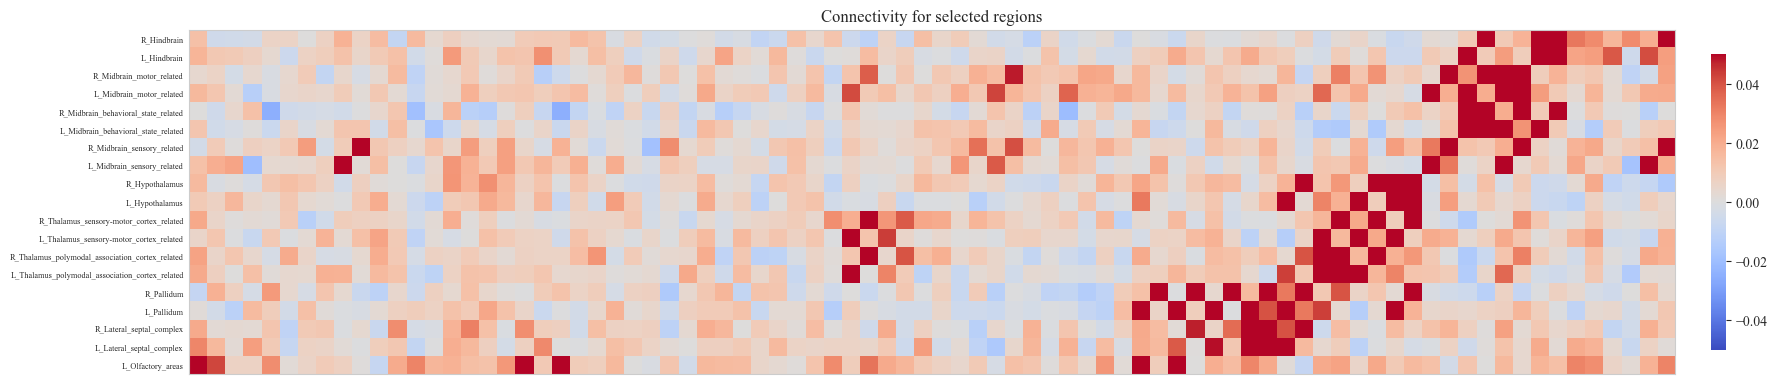

In [5]:
import matplotlib.pyplot as plt

region_labels = labels_12_list  # example

regions_list = [1, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76]

fig, ax = plt.subplots(figsize=(20, 20))
plot_conn_rows(
    ax,
    PBS_s1_correlation_KDhet,
    regions_list=regions_list,
    labels=region_labels,
    vmin=-0.05, vmax=0.05,
    cmap="coolwarm",
    colorbar=True
)
ax.set_title("Connectivity for selected regions")
plt.tight_layout()
plt.show()